In [5]:
# ANALISIS PERBANDINGAN ALGORITMA FCFS, SJF, DAN PRIORITY SCHEDULING
## PADA PENJADWALAN PRODUKSI INDUSTRI MANUFAKTUR

#SURYA WAJDIY - 252321043

#Dataset:
#`hybrid_manufacturing_categorical.csv`

#Algoritma:
#1. First Come First Serve (FCFS)
#2. Shortest Job First (SJF)
#3. Priority Scheduling

#Tujuan:
#Menganalisis dan membandingkan kinerja FCFS, SJF, dan Priority Scheduling
#berdasarkan Average Waiting Time, Average Turnaround Time,
#verage Response Time, Makespan, dan Throughput.

In [6]:
# ============================================================
# CELL 1 - IMPORT LIBRARY
# ============================================================

# Mengimpor pandas untuk pengolahan dataset dan tabel.
import pandas as pd

# Mengimpor numpy untuk operasi numerik.
import numpy as np

# Mengimpor matplotlib untuk membuat grafik.
import matplotlib.pyplot as plt

# Mengimpor os untuk mengelola folder dan file.
import os

# Mengimpor shutil untuk membuat file ZIP.
import shutil

# Mengimpor zipfile untuk proses kompresi hasil.
import zipfile

# Mengimpor display agar tabel DataFrame tampil lebih rapi di Colab.
from IPython.display import display

# Mengimpor fungsi files untuk melakukan download file dari Google Colab.
from google.colab import files

# Mengatur tampilan angka pandas agar lebih mudah dibaca.
pd.set_option("display.max_columns", None)

# Mengatur jumlah baris yang dapat ditampilkan.
pd.set_option("display.max_rows", 100)

# Mengatur jumlah angka desimal.
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Library berhasil diimpor.")

Library berhasil diimpor.


In [7]:
# ============================================================
# CELL 2 - UPLOAD DATASET
# ============================================================

# Nama file dataset yang digunakan dalam penelitian.
FILE_NAME = "hybrid_manufacturing_categorical.csv"

# Memeriksa apakah file sudah tersedia di Google Colab.
if not os.path.exists(FILE_NAME):

    # Jika belum ada, pengguna diminta meng-upload dataset.
    print(f"File '{FILE_NAME}' belum ditemukan.")
    print("Silakan upload dataset Anda.")

    uploaded = files.upload()

    # Memastikan file yang di-upload memiliki nama yang benar.
    if FILE_NAME not in uploaded:
        raise FileNotFoundError(
            f"File yang di-upload harus bernama '{FILE_NAME}'."
        )

# Menampilkan informasi bahwa file telah ditemukan.
print(f"Dataset ditemukan: {FILE_NAME}")

Dataset ditemukan: hybrid_manufacturing_categorical.csv


In [8]:
# ============================================================
# CELL 3 - MEMBACA DATASET
# ============================================================

# Membaca file CSV menggunakan pandas.
df = pd.read_csv(FILE_NAME)

# Menampilkan jumlah baris dan kolom.
print("Ukuran dataset:")
print(f"Jumlah data  : {df.shape[0]}")
print(f"Jumlah kolom : {df.shape[1]}")

# Menampilkan lima data pertama.
print("\nLima data pertama:")
display(df.head())

Ukuran dataset:
Jumlah data  : 1000
Jumlah kolom : 13

Lima data pertama:


,Job_ID,Machine_ID,Operation_Type,Material_Used,Processing_Time,Energy_Consumption,Machine_Availability,Scheduled_Start,Scheduled_End,Actual_Start,Actual_End,Job_Status,Optimization_Category
0,J001,M01,Grinding,3.17,76,11.42,96,2023-03-18 08:00:00,2023-03-18 09:16:00,2023-03-18 08:05:00,2023-03-18 09:21:00,Completed,Moderate Efficiency
1,J002,M01,Grinding,3.35,79,6.61,84,2023-03-18 08:10:00,2023-03-18 09:29:00,2023-03-18 08:20:00,2023-03-18 09:39:00,Delayed,Low Efficiency
2,J003,M04,Additive,2.29,56,11.11,92,2023-03-18 08:20:00,2023-03-18 09:16:00,NaN,NaN,Failed,Low Efficiency
3,J004,M04,Grinding,1.76,106,12.50,95,2023-03-18 08:30:00,2023-03-18 10:16:00,2023-03-18 08:35:00,2023-03-18 10:21:00,Completed,Moderate Efficiency
4,J005,M01,Lathe,1.90,46,8.13,88,2023-03-18 08:40:00,2023-03-18 09:26:00,2023-03-18 08:42:00,2023-03-18 09:28:00,Completed,High Efficiency


In [9]:
# ============================================================
# CELL 4 - PEMERIKSAAN STRUKTUR DATASET
# ============================================================

# Menampilkan nama seluruh kolom.
print("Nama kolom dataset:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

# Menampilkan tipe data setiap kolom.
print("\nTipe data setiap kolom:")
display(df.dtypes.to_frame("Data Type"))

# Menampilkan jumlah missing value setiap kolom.
print("\nJumlah missing value:")
missing_table = df.isnull().sum().to_frame("Missing Value")
missing_table["Persentase (%)"] = (
    missing_table["Missing Value"] / len(df) * 100
)
display(missing_table)

# Menampilkan jumlah data duplikat.
print("\nJumlah data duplikat:")
print(df.duplicated().sum())

Nama kolom dataset:
1. Job_ID
2. Machine_ID
3. Operation_Type
4. Material_Used
5. Processing_Time
6. Energy_Consumption
7. Machine_Availability
8. Scheduled_Start
9. Scheduled_End
10. Actual_Start
11. Actual_End
12. Job_Status
13. Optimization_Category

Tipe data setiap kolom:


,Data Type
Job_ID,object
Machine_ID,object
Operation_Type,object
Material_Used,float64
Processing_Time,int64
Energy_Consumption,float64
Machine_Availability,int64
Scheduled_Start,object
Scheduled_End,object
Actual_Start,object



Jumlah missing value:


,Missing Value,Persentase (%)
Job_ID,0,0.00
Machine_ID,0,0.00
Operation_Type,0,0.00
Material_Used,0,0.00
Processing_Time,0,0.00
Energy_Consumption,0,0.00
Machine_Availability,0,0.00
Scheduled_Start,0,0.00
Scheduled_End,0,0.00
Actual_Start,129,12.90



Jumlah data duplikat:
0


In [10]:
# ============================================================
# CELL 5 - VALIDASI KOLOM DATASET
# ============================================================

# Daftar kolom yang memang dibutuhkan oleh penelitian.
required_columns = [
    "Job_ID",
    "Machine_ID",
    "Operation_Type",
    "Material_Used",
    "Processing_Time",
    "Energy_Consumption",
    "Machine_Availability",
    "Scheduled_Start",
    "Scheduled_End",
    "Actual_Start",
    "Actual_End",
    "Job_Status",
    "Optimization_Category"
]

# Mencari kolom yang belum tersedia.
missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

# Jika terdapat kolom yang hilang, program dihentikan.
if missing_columns:
    raise ValueError(
        "Dataset tidak sesuai. Kolom berikut tidak ditemukan:\n"
        + "\n".join(missing_columns)
    )

print("VALIDASI DATASET BERHASIL.")
print("Semua kolom yang diperlukan tersedia.")

# Menampilkan jumlah data.
print(f"\nJumlah job: {len(df)}")

# Menampilkan jumlah mesin.
print(f"Jumlah mesin: {df['Machine_ID'].nunique()}")

# Menampilkan daftar mesin.
print("\nDaftar mesin:")
print(sorted(df["Machine_ID"].dropna().unique()))

VALIDASI DATASET BERHASIL.
Semua kolom yang diperlukan tersedia.

Jumlah job: 1000
Jumlah mesin: 5

Daftar mesin:
['M01', 'M02', 'M03', 'M04', 'M05']


In [11]:
# ============================================================
# CELL 6 - PREPROCESSING DATA
# ============================================================

# Membuat salinan dataset agar data asli tetap aman.
data = df.copy()

# Mengubah Scheduled_Start menjadi tipe datetime.
data["Scheduled_Start"] = pd.to_datetime(
    data["Scheduled_Start"],
    errors="coerce"
)

# Mengubah Scheduled_End menjadi tipe datetime.
data["Scheduled_End"] = pd.to_datetime(
    data["Scheduled_End"],
    errors="coerce"
)

# Mengubah Actual_Start menjadi tipe datetime.
data["Actual_Start"] = pd.to_datetime(
    data["Actual_Start"],
    errors="coerce"
)

# Mengubah Actual_End menjadi tipe datetime.
data["Actual_End"] = pd.to_datetime(
    data["Actual_End"],
    errors="coerce"
)

# Memastikan Processing_Time berupa angka.
data["Processing_Time"] = pd.to_numeric(
    data["Processing_Time"],
    errors="coerce"
)

# Memastikan Energy_Consumption berupa angka.
data["Energy_Consumption"] = pd.to_numeric(
    data["Energy_Consumption"],
    errors="coerce"
)

# Memastikan Machine_Availability berupa angka.
data["Machine_Availability"] = pd.to_numeric(
    data["Machine_Availability"],
    errors="coerce"
)

# Menghapus baris yang tidak memiliki data penting untuk simulasi.
data = data.dropna(
    subset=[
        "Job_ID",
        "Machine_ID",
        "Processing_Time",
        "Scheduled_Start"
    ]
).copy()

# Memastikan Processing_Time bernilai positif.
data = data[data["Processing_Time"] > 0].copy()

# Mengurutkan berdasarkan mesin dan Scheduled_Start.
data = data.sort_values(
    by=["Machine_ID", "Scheduled_Start", "Job_ID"]
).reset_index(drop=True)

print("Preprocessing selesai.")
print(f"Jumlah data setelah preprocessing: {len(data)}")

display(data.head())

Preprocessing selesai.
Jumlah data setelah preprocessing: 1000


,Job_ID,Machine_ID,Operation_Type,Material_Used,Processing_Time,Energy_Consumption,Machine_Availability,Scheduled_Start,Scheduled_End,Actual_Start,Actual_End,Job_Status,Optimization_Category
0,J001,M01,Grinding,3.17,76,11.42,96,2023-03-18 08:00:00,2023-03-18 09:16:00,2023-03-18 08:05:00,2023-03-18 09:21:00,Completed,Moderate Efficiency
1,J002,M01,Grinding,3.35,79,6.61,84,2023-03-18 08:10:00,2023-03-18 09:29:00,2023-03-18 08:20:00,2023-03-18 09:39:00,Delayed,Low Efficiency
2,J005,M01,Lathe,1.90,46,8.13,88,2023-03-18 08:40:00,2023-03-18 09:26:00,2023-03-18 08:42:00,2023-03-18 09:28:00,Completed,High Efficiency
3,J010,M01,Drilling,2.10,27,3.66,97,2023-03-18 09:30:00,2023-03-18 09:57:00,2023-03-18 09:54:00,2023-03-18 10:21:00,Delayed,Low Efficiency
4,J011,M01,Lathe,3.02,65,9.98,90,2023-03-18 09:40:00,2023-03-18 10:45:00,2023-03-18 09:38:00,2023-03-18 10:43:00,Completed,Low Efficiency


In [12]:
# ============================================================
# CELL 7 - PEMBENTUKAN PRIORITAS SIMULASI
# ============================================================

# Membuat pemetaan kategori efisiensi menjadi level prioritas.
priority_mapping = {
    "High Efficiency": 1,
    "Moderate Efficiency": 2,
    "Low Efficiency": 3
}

# Membuat kolom prioritas turunan.
data["Derived_Priority"] = (
    data["Optimization_Category"]
    .astype(str)
    .str.strip()
    .map(priority_mapping)
)

# Jika ada kategori yang tidak dikenali,
# prioritas tersebut diberi nilai 3 sebagai prioritas terendah.
data["Derived_Priority"] = data["Derived_Priority"].fillna(3).astype(int)

# Menampilkan distribusi prioritas.
priority_distribution = (
    data["Derived_Priority"]
    .value_counts()
    .sort_index()
    .rename_axis("Priority")
    .reset_index(name="Jumlah Job")
)

print("Distribusi prioritas simulasi:")
display(priority_distribution)

# Menampilkan hubungan kategori dengan prioritas.
priority_reference = (
    data[
        ["Optimization_Category", "Derived_Priority"]
    ]
    .drop_duplicates()
    .sort_values("Derived_Priority")
)

print("Mapping prioritas:")
display(priority_reference)

Distribusi prioritas simulasi:


,Priority,Jumlah Job
0,1,161
1,2,183
2,3,656


Mapping prioritas:


,Optimization_Category,Derived_Priority
2,High Efficiency,1
0,Moderate Efficiency,2
1,Low Efficiency,3
94,Optimal Efficiency,3


In [13]:
# ============================================================
# CELL 8 - DATA DASAR SIMULASI PENJADWALAN
# ============================================================

# Membuat salinan data untuk simulasi.
simulation_data = data.copy()

# Membuat waktu release relatif untuk setiap mesin.
# Nilai 0 berarti job tersebut merupakan job pertama
# yang tersedia pada mesin tersebut.
simulation_data["Release_Time"] = (
    simulation_data["Scheduled_Start"]
    - simulation_data.groupby("Machine_ID")["Scheduled_Start"].transform("min")
).dt.total_seconds() / 60

# Release_Time digunakan sebagai urutan waktu kedatangan.
# Processing_Time tetap menggunakan nilai asli dataset.
simulation_data["Processing_Duration"] = (
    simulation_data["Processing_Time"].astype(float)
)

# Menampilkan data dasar simulasi.
simulation_columns = [
    "Job_ID",
    "Machine_ID",
    "Scheduled_Start",
    "Processing_Time",
    "Processing_Duration",
    "Release_Time",
    "Derived_Priority",
    "Optimization_Category"
]

display(
    simulation_data[simulation_columns].head(20)
)

,Job_ID,Machine_ID,Scheduled_Start,Processing_Time,Processing_Duration,Release_Time,Derived_Priority,Optimization_Category
0,J001,M01,2023-03-18 08:00:00,76,76.00,0.00,2,Moderate Efficiency
1,J002,M01,2023-03-18 08:10:00,79,79.00,10.00,3,Low Efficiency
2,J005,M01,2023-03-18 08:40:00,46,46.00,40.00,1,High Efficiency
3,J010,M01,2023-03-18 09:30:00,27,27.00,90.00,3,Low Efficiency
4,J011,M01,2023-03-18 09:40:00,65,65.00,100.00,3,Low Efficiency
5,J016,M01,2023-03-18 10:30:00,65,65.00,150.00,3,Low Efficiency
6,J023,M01,2023-03-18 11:40:00,98,98.00,220.00,3,Low Efficiency
7,J026,M01,2023-03-18 12:10:00,21,21.00,250.00,1,High Efficiency
8,J034,M01,2023-03-18 13:30:00,110,110.00,330.00,3,Low Efficiency
9,J037,M01,2023-03-18 14:00:00,79,79.00,360.00,2,Moderate Efficiency


In [14]:
# ============================================================
# CELL 9 - ALGORITMA FCFS
# ============================================================

def schedule_fcfs(machine_data):
    """
    Menjadwalkan job menggunakan algoritma FCFS.

    Prinsip:
    Job yang datang/tersedia lebih dahulu akan diproses lebih dahulu.
    """

    # Mengurutkan job berdasarkan waktu release.
    jobs = machine_data.sort_values(
        by=["Release_Time", "Job_ID"]
    ).copy()

    # Menyimpan hasil penjadwalan.
    results = []

    # Waktu mesin mulai dari waktu 0.
    current_time = 0.0

    # Memproses job satu per satu.
    for _, job in jobs.iterrows():

        # Mesin harus menunggu jika job belum tersedia.
        start_time = max(
            current_time,
            float(job["Release_Time"])
        )

        # Completion time = start + processing duration.
        completion_time = (
            start_time +
            float(job["Processing_Duration"])
        )

        # Waiting time = waktu mulai - waktu release.
        waiting_time = (
            start_time -
            float(job["Release_Time"])
        )

        # Turnaround time = completion - release.
        turnaround_time = (
            completion_time -
            float(job["Release_Time"])
        )

        # Response time untuk non-preemptive scheduling
        # sama dengan start - release.
        response_time = waiting_time

        # Menyimpan hasil.
        results.append({
            "Job_ID": job["Job_ID"],
            "Machine_ID": job["Machine_ID"],
            "Scheduled_Start": job["Scheduled_Start"],
            "Processing_Time": job["Processing_Time"],
            "Derived_Priority": job["Derived_Priority"],
            "Start_Time": start_time,
            "Completion_Time": completion_time,
            "Waiting_Time": waiting_time,
            "Turnaround_Time": turnaround_time,
            "Response_Time": response_time
        })

        # Memperbarui waktu mesin.
        current_time = completion_time

    # Mengembalikan hasil sebagai DataFrame.
    return pd.DataFrame(results)

In [15]:
# ============================================================
# CELL 10 - ALGORITMA SJF
# ============================================================

def schedule_sjf(machine_data):
    """
    Menjadwalkan job menggunakan Shortest Job First.

    Prinsip:
    Dari job yang sudah tersedia, job dengan Processing_Time
    paling kecil diproses terlebih dahulu.

    SJF yang digunakan adalah non-preemptive.
    """

    # Membuat salinan data.
    jobs = machine_data.copy()

    # Menyimpan hasil.
    results = []

    # Menyimpan index job yang belum diproses.
    remaining = set(jobs.index)

    # Waktu mesin.
    current_time = 0.0

    # Melakukan proses sampai semua job selesai.
    while remaining:

        # Mencari job yang sudah tersedia.
        available = [
            idx for idx in remaining
            if float(jobs.loc[idx, "Release_Time"]) <= current_time
        ]

        # Jika belum ada job yang tersedia,
        # waktu dimajukan ke job berikutnya yang datang.
        if not available:

            next_idx = min(
                remaining,
                key=lambda idx: (
                    float(jobs.loc[idx, "Release_Time"]),
                    str(jobs.loc[idx, "Job_ID"])
                )
            )

            current_time = max(
                current_time,
                float(jobs.loc[next_idx, "Release_Time"])
            )

            available = [
                idx for idx in remaining
                if float(jobs.loc[idx, "Release_Time"]) <= current_time
            ]

        # Memilih processing time paling kecil.
        selected_idx = min(
            available,
            key=lambda idx: (
                float(jobs.loc[idx, "Processing_Duration"]),
                float(jobs.loc[idx, "Release_Time"]),
                str(jobs.loc[idx, "Job_ID"])
            )
        )

        # Mengambil data job.
        job = jobs.loc[selected_idx]

        # Menentukan waktu mulai.
        start_time = max(
            current_time,
            float(job["Release_Time"])
        )

        # Menghitung waktu selesai.
        completion_time = (
            start_time +
            float(job["Processing_Duration"])
        )

        # Menghitung waiting time.
        waiting_time = (
            start_time -
            float(job["Release_Time"])
        )

        # Menghitung turnaround time.
        turnaround_time = (
            completion_time -
            float(job["Release_Time"])
        )

        # Response time pada non-preemptive SJF.
        response_time = waiting_time

        # Menyimpan hasil.
        results.append({
            "Job_ID": job["Job_ID"],
            "Machine_ID": job["Machine_ID"],
            "Scheduled_Start": job["Scheduled_Start"],
            "Processing_Time": job["Processing_Time"],
            "Derived_Priority": job["Derived_Priority"],
            "Start_Time": start_time,
            "Completion_Time": completion_time,
            "Waiting_Time": waiting_time,
            "Turnaround_Time": turnaround_time,
            "Response_Time": response_time
        })

        # Memperbarui waktu mesin.
        current_time = completion_time

        # Menghapus job yang sudah selesai.
        remaining.remove(selected_idx)

    # Mengubah hasil menjadi DataFrame.
    return pd.DataFrame(results)

In [16]:
# ============================================================
# CELL 11 - ALGORITMA PRIORITY SCHEDULING
# ============================================================

def schedule_priority(machine_data):
    """
    Menjadwalkan job menggunakan Priority Scheduling.

    Priority 1 = tertinggi
    Priority 2 = sedang
    Priority 3 = terendah

    Jika priority sama, Scheduled_Start digunakan
    sebagai aturan pemecah ties.
    """

    # Membuat salinan data.
    jobs = machine_data.copy()

    # Menyimpan hasil.
    results = []

    # Menyimpan job yang belum diproses.
    remaining = set(jobs.index)

    # Waktu mesin.
    current_time = 0.0

    # Melakukan proses sampai semua job selesai.
    while remaining:

        # Mencari job yang sudah tersedia.
        available = [
            idx for idx in remaining
            if float(jobs.loc[idx, "Release_Time"]) <= current_time
        ]

        # Jika belum ada job yang tersedia,
        # mesin menunggu job berikutnya.
        if not available:

            next_idx = min(
                remaining,
                key=lambda idx: (
                    float(jobs.loc[idx, "Release_Time"]),
                    str(jobs.loc[idx, "Job_ID"])
                )
            )

            current_time = max(
                current_time,
                float(jobs.loc[next_idx, "Release_Time"])
            )

            available = [
                idx for idx in remaining
                if float(jobs.loc[idx, "Release_Time"]) <= current_time
            ]

        # Memilih priority paling tinggi.
        selected_idx = min(
            available,
            key=lambda idx: (
                int(jobs.loc[idx, "Derived_Priority"]),
                float(jobs.loc[idx, "Release_Time"]),
                str(jobs.loc[idx, "Job_ID"])
            )
        )

        # Mengambil data job.
        job = jobs.loc[selected_idx]

        # Menentukan waktu mulai.
        start_time = max(
            current_time,
            float(job["Release_Time"])
        )

        # Menghitung waktu selesai.
        completion_time = (
            start_time +
            float(job["Processing_Duration"])
        )

        # Menghitung waiting time.
        waiting_time = (
            start_time -
            float(job["Release_Time"])
        )

        # Menghitung turnaround time.
        turnaround_time = (
            completion_time -
            float(job["Release_Time"])
        )

        # Response time untuk non-preemptive scheduling.
        response_time = waiting_time

        # Menyimpan hasil.
        results.append({
            "Job_ID": job["Job_ID"],
            "Machine_ID": job["Machine_ID"],
            "Scheduled_Start": job["Scheduled_Start"],
            "Processing_Time": job["Processing_Time"],
            "Derived_Priority": job["Derived_Priority"],
            "Start_Time": start_time,
            "Completion_Time": completion_time,
            "Waiting_Time": waiting_time,
            "Turnaround_Time": turnaround_time,
            "Response_Time": response_time
        })

        # Memperbarui waktu mesin.
        current_time = completion_time

        # Menghapus job yang sudah selesai.
        remaining.remove(selected_idx)

    # Mengembalikan hasil.
    return pd.DataFrame(results)

In [17]:
# ============================================================
# CELL 12 - MENJALANKAN FCFS, SJF, DAN PRIORITY
# ============================================================

# Dictionary untuk menyimpan hasil seluruh algoritma.
all_results = {}

# =========================================================
# FCFS
# =========================================================

fcfs_list = []

# Penjadwalan dilakukan untuk setiap mesin.
for machine_id, machine_data in simulation_data.groupby("Machine_ID"):

    # Menjalankan FCFS pada mesin tersebut.
    result = schedule_fcfs(machine_data)

    # Menambahkan hasil.
    fcfs_list.append(result)

# Menggabungkan seluruh mesin.
fcfs_result = pd.concat(
    fcfs_list,
    ignore_index=True
)

# Menyimpan hasil FCFS.
all_results["FCFS"] = fcfs_result


# =========================================================
# SJF
# =========================================================

sjf_list = []

# Menjalankan SJF untuk setiap mesin.
for machine_id, machine_data in simulation_data.groupby("Machine_ID"):

    # Menjalankan SJF.
    result = schedule_sjf(machine_data)

    # Menambahkan hasil.
    sjf_list.append(result)

# Menggabungkan seluruh mesin.
sjf_result = pd.concat(
    sjf_list,
    ignore_index=True
)

# Menyimpan hasil SJF.
all_results["SJF"] = sjf_result


# =========================================================
# PRIORITY
# =========================================================

priority_list = []

# Menjalankan Priority Scheduling untuk setiap mesin.
for machine_id, machine_data in simulation_data.groupby("Machine_ID"):

    # Menjalankan Priority Scheduling.
    result = schedule_priority(machine_data)

    # Menambahkan hasil.
    priority_list.append(result)

# Menggabungkan seluruh mesin.
priority_result = pd.concat(
    priority_list,
    ignore_index=True
)

# Menyimpan hasil Priority.
all_results["Priority Scheduling"] = priority_result


# =========================================================
# MENAMPILKAN INFORMASI
# =========================================================

print("Semua algoritma berhasil dijalankan.")

print(f"Jumlah hasil FCFS     : {len(fcfs_result)}")
print(f"Jumlah hasil SJF      : {len(sjf_result)}")
print(f"Jumlah hasil Priority : {len(priority_result)}")

Semua algoritma berhasil dijalankan.
Jumlah hasil FCFS     : 1000
Jumlah hasil SJF      : 1000
Jumlah hasil Priority : 1000


In [18]:
# ============================================================
# CELL 13 - TABEL HASIL FCFS
# ============================================================

print("=" * 80)
print("HASIL PENJADWALAN FCFS")
print("=" * 80)

display(
    fcfs_result.sort_values(
        by=["Machine_ID", "Start_Time"]
    ).reset_index(drop=True)
)

HASIL PENJADWALAN FCFS


,Job_ID,Machine_ID,Scheduled_Start,Processing_Time,Derived_Priority,Start_Time,Completion_Time,Waiting_Time,Turnaround_Time,Response_Time
0,J001,M01,2023-03-18 08:00:00,76,2,0.00,76.00,0.00,76.00,0.00
1,J002,M01,2023-03-18 08:10:00,79,3,76.00,155.00,66.00,145.00,66.00
2,J005,M01,2023-03-18 08:40:00,46,1,155.00,201.00,115.00,161.00,115.00
3,J010,M01,2023-03-18 09:30:00,27,3,201.00,228.00,111.00,138.00,111.00
4,J011,M01,2023-03-18 09:40:00,65,3,228.00,293.00,128.00,193.00,128.00
...,...,...,...,...,...,...,...,...,...,...
995,J986,M05,2023-03-25 04:10:00,60,1,"13,313.00","13,373.00","3,533.00","3,593.00","3,533.00"
996,J993,M05,2023-03-25 05:20:00,105,3,"13,373.00","13,478.00","3,523.00","3,628.00","3,523.00"
997,J994,M05,2023-03-25 05:30:00,94,3,"13,478.00","13,572.00","3,618.00","3,712.00","3,618.00"
998,J997,M05,2023-03-25 06:00:00,60,3,"13,572.00","13,632.00","3,682.00","3,742.00","3,682.00"


In [19]:
# ============================================================
# CELL 14 - TABEL HASIL SJF
# ============================================================

print("=" * 80)
print("HASIL PENJADWALAN SJF")
print("=" * 80)

display(
    sjf_result.sort_values(
        by=["Machine_ID", "Start_Time"]
    ).reset_index(drop=True)
)

HASIL PENJADWALAN SJF


,Job_ID,Machine_ID,Scheduled_Start,Processing_Time,Derived_Priority,Start_Time,Completion_Time,Waiting_Time,Turnaround_Time,Response_Time
0,J001,M01,2023-03-18 08:00:00,76,2,0.00,76.00,0.00,76.00,0.00
1,J005,M01,2023-03-18 08:40:00,46,1,76.00,122.00,36.00,82.00,36.00
2,J010,M01,2023-03-18 09:30:00,27,3,122.00,149.00,32.00,59.00,32.00
3,J011,M01,2023-03-18 09:40:00,65,3,149.00,214.00,49.00,114.00,49.00
4,J016,M01,2023-03-18 10:30:00,65,3,214.00,279.00,64.00,129.00,64.00
...,...,...,...,...,...,...,...,...,...,...
995,J506,M05,2023-03-21 20:10:00,117,3,"13,150.00","13,267.00","8,170.00","8,287.00","8,170.00"
996,J726,M05,2023-03-23 08:50:00,117,3,"13,267.00","13,384.00","6,087.00","6,204.00","6,087.00"
997,J813,M05,2023-03-23 23:20:00,119,1,"13,384.00","13,503.00","5,334.00","5,453.00","5,334.00"
998,J575,M05,2023-03-22 07:40:00,120,3,"13,503.00","13,623.00","7,833.00","7,953.00","7,833.00"


In [20]:
# ============================================================
# CELL 15 - TABEL HASIL PRIORITY SCHEDULING
# ============================================================

print("=" * 80)
print("HASIL PENJADWALAN PRIORITY SCHEDULING")
print("=" * 80)

display(
    priority_result.sort_values(
        by=["Machine_ID", "Start_Time"]
    ).reset_index(drop=True)
)

HASIL PENJADWALAN PRIORITY SCHEDULING


,Job_ID,Machine_ID,Scheduled_Start,Processing_Time,Derived_Priority,Start_Time,Completion_Time,Waiting_Time,Turnaround_Time,Response_Time
0,J001,M01,2023-03-18 08:00:00,76,2,0.00,76.00,0.00,76.00,0.00
1,J005,M01,2023-03-18 08:40:00,46,1,76.00,122.00,36.00,82.00,36.00
2,J002,M01,2023-03-18 08:10:00,79,3,122.00,201.00,112.00,191.00,112.00
3,J010,M01,2023-03-18 09:30:00,27,3,201.00,228.00,111.00,138.00,111.00
4,J011,M01,2023-03-18 09:40:00,65,3,228.00,293.00,128.00,193.00,128.00
...,...,...,...,...,...,...,...,...,...,...
995,J983,M05,2023-03-25 03:40:00,46,3,"13,327.00","13,373.00","3,577.00","3,623.00","3,577.00"
996,J993,M05,2023-03-25 05:20:00,105,3,"13,373.00","13,478.00","3,523.00","3,628.00","3,523.00"
997,J994,M05,2023-03-25 05:30:00,94,3,"13,478.00","13,572.00","3,618.00","3,712.00","3,618.00"
998,J997,M05,2023-03-25 06:00:00,60,3,"13,572.00","13,632.00","3,682.00","3,742.00","3,682.00"


In [21]:
# ============================================================
# CELL 16 - FUNGSI EVALUASI KINERJA
# ============================================================

def calculate_metrics(result):
    """
    Menghitung metrik kinerja algoritma scheduling.
    """

    # Rata-rata waktu tunggu.
    average_waiting = result["Waiting_Time"].mean()

    # Rata-rata turnaround time.
    average_turnaround = result["Turnaround_Time"].mean()

    # Rata-rata response time.
    average_response = result["Response_Time"].mean()

    # Waktu selesai paling akhir.
    last_completion = result["Completion_Time"].max()

    # Waktu release paling awal.
    first_release = (
        result["Scheduled_Start"].min()
    )

    # Makespan simulasi dihitung dari rentang
    # waktu release relatif sampai job terakhir selesai.
    first_release_relative = result["Scheduled_Start"].min()

    # Menghitung release relatif dari Scheduled_Start.
    release_relative = (
        result["Scheduled_Start"]
        - result["Scheduled_Start"].min()
    ).dt.total_seconds() / 60

    # Karena hasil per mesin memiliki Release_Time
    # masing-masing, gunakan completion maksimum
    # sebagai makespan global relatif.
    makespan = result["Completion_Time"].max()

    # Jumlah job.
    total_jobs = len(result)

    # Throughput = jumlah job / makespan.
    throughput = (
        total_jobs / makespan
        if makespan > 0
        else 0
    )

    # Mengembalikan dictionary metrik.
    return {
        "Average Waiting Time": average_waiting,
        "Average Turnaround Time": average_turnaround,
        "Average Response Time": average_response,
        "Makespan": makespan,
        "Throughput": throughput
    }

In [22]:
# ============================================================
# CELL 17 - TABEL PERBANDINGAN ALGORITMA
# ============================================================

# Menghitung metrik FCFS.
fcfs_metrics = calculate_metrics(fcfs_result)

# Menghitung metrik SJF.
sjf_metrics = calculate_metrics(sjf_result)

# Menghitung metrik Priority.
priority_metrics = calculate_metrics(priority_result)

# Membuat tabel perbandingan.
comparison = pd.DataFrame(
    [
        {
            "Algorithm": "FCFS",
            **fcfs_metrics
        },
        {
            "Algorithm": "SJF",
            **sjf_metrics
        },
        {
            "Algorithm": "Priority Scheduling",
            **priority_metrics
        }
    ]
)

# Menampilkan tabel.
print("=" * 90)
print("PERBANDINGAN KINERJA ALGORITMA")
print("=" * 90)

display(comparison)

PERBANDINGAN KINERJA ALGORITMA


,Algorithm,Average Waiting Time,Average Turnaround Time,Average Response Time,Makespan,Throughput
0,FCFS,"2,116.74","2,188.12","2,116.74","15,545.00",0.06
1,SJF,"1,411.12","1,482.51","1,411.12","15,545.00",0.06
2,Priority Scheduling,"2,092.44","2,163.82","2,092.44","15,545.00",0.06


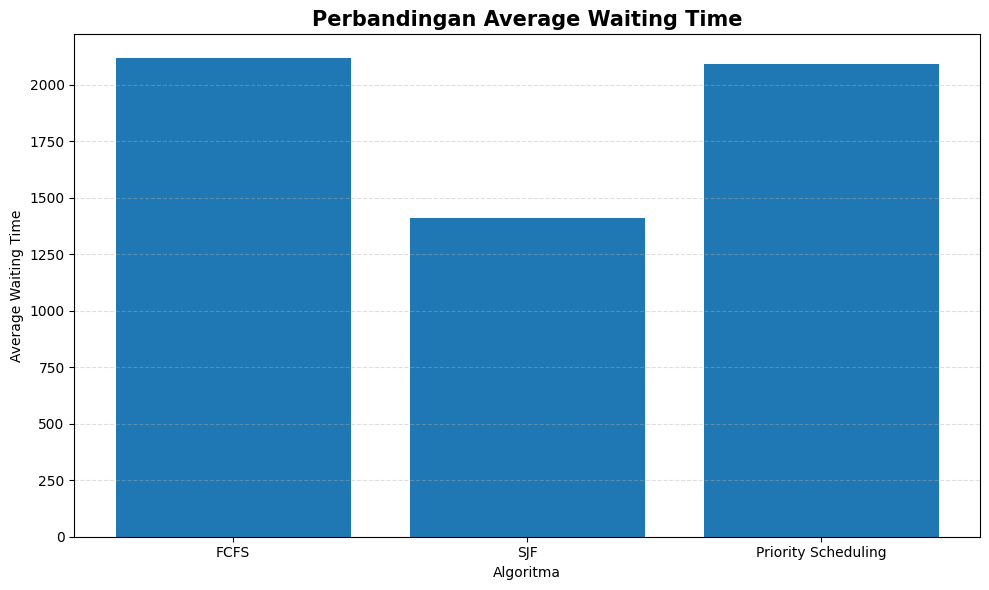

In [23]:
# ============================================================
# CELL 18 - GRAFIK AVERAGE WAITING TIME
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Algorithm"],
    comparison["Average Waiting Time"]
)

plt.title(
    "Perbandingan Average Waiting Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Algoritma")
plt.ylabel("Average Waiting Time")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

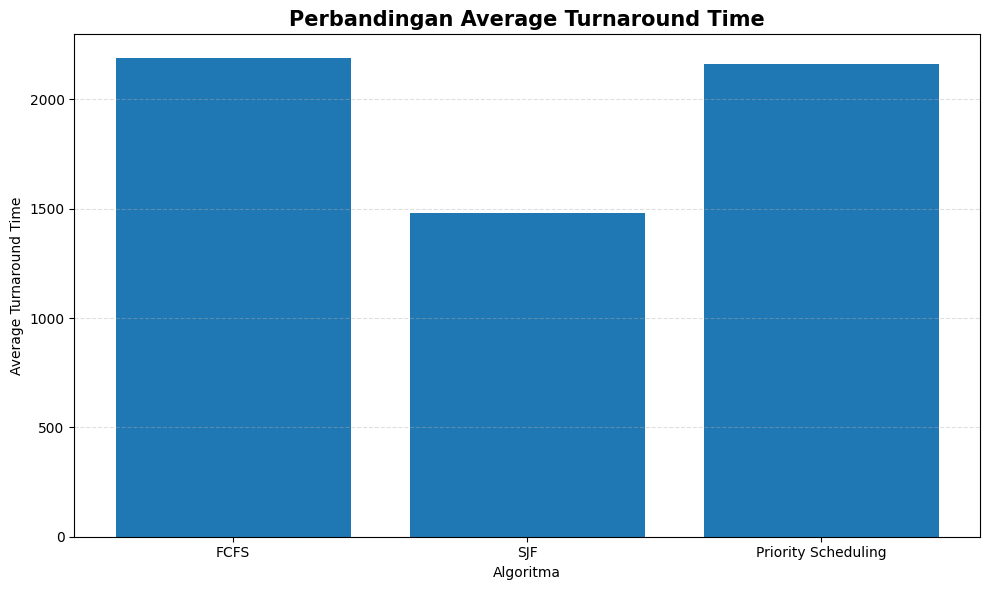

In [24]:
# ============================================================
# CELL 19 - GRAFIK AVERAGE TURNAROUND TIME
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Algorithm"],
    comparison["Average Turnaround Time"]
)

plt.title(
    "Perbandingan Average Turnaround Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Algoritma")
plt.ylabel("Average Turnaround Time")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

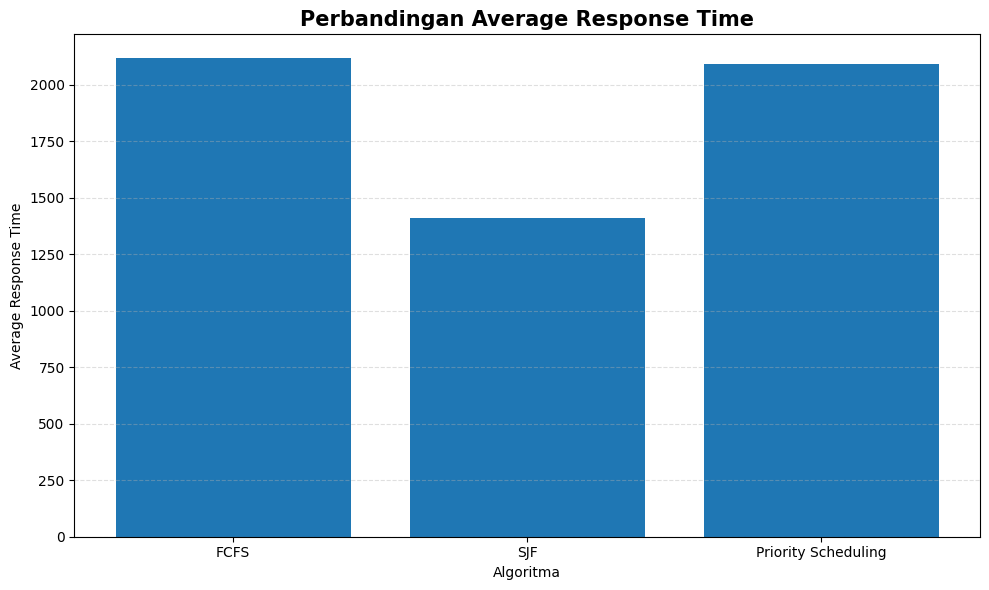

In [25]:
# ============================================================
# CELL 20 - GRAFIK AVERAGE RESPONSE TIME
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Algorithm"],
    comparison["Average Response Time"]
)

plt.title(
    "Perbandingan Average Response Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Algoritma")
plt.ylabel("Average Response Time")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

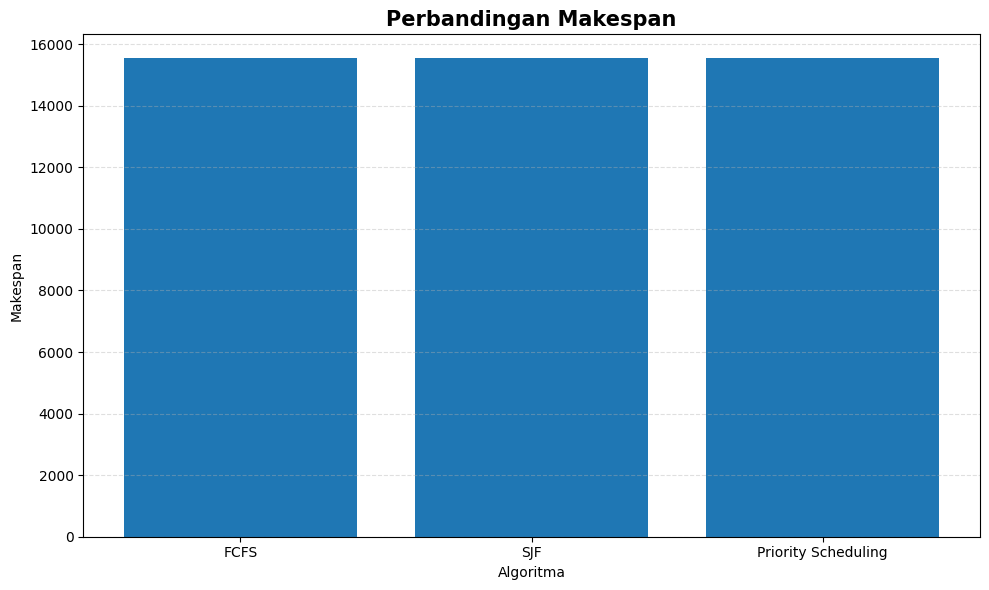

In [26]:
# ============================================================
# CELL 21 - GRAFIK MAKESPAN
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Algorithm"],
    comparison["Makespan"]
)

plt.title(
    "Perbandingan Makespan",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Algoritma")
plt.ylabel("Makespan")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

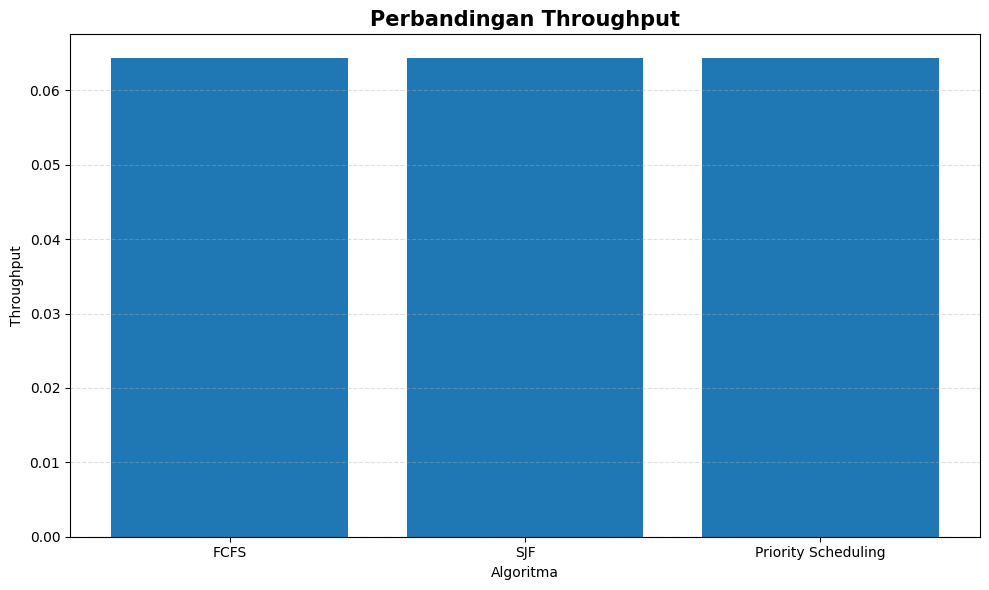

In [27]:
# ============================================================
# CELL 22 - GRAFIK THROUGHPUT
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    comparison["Algorithm"],
    comparison["Throughput"]
)

plt.title(
    "Perbandingan Throughput",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Algoritma")
plt.ylabel("Throughput")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

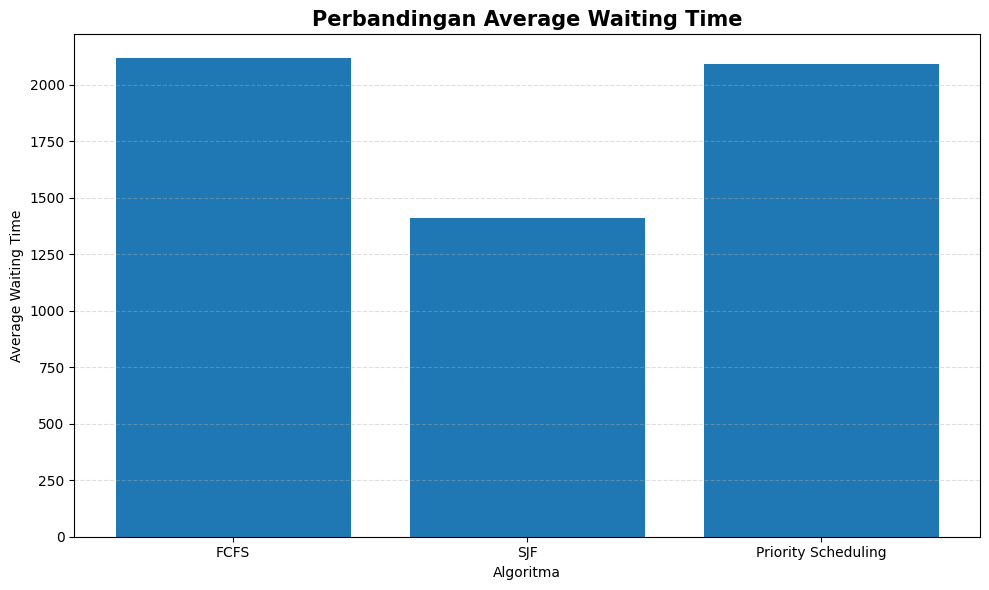

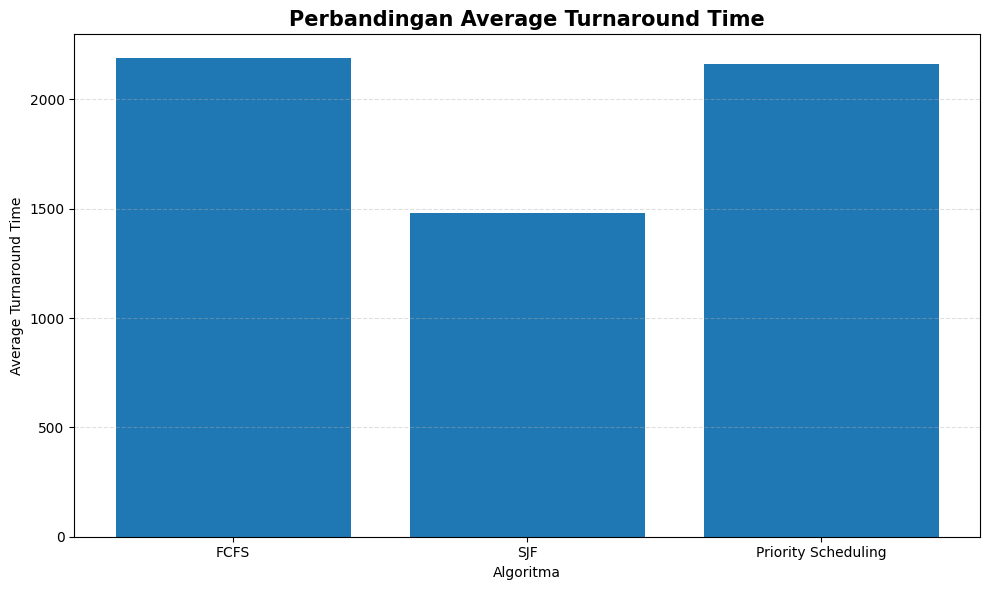

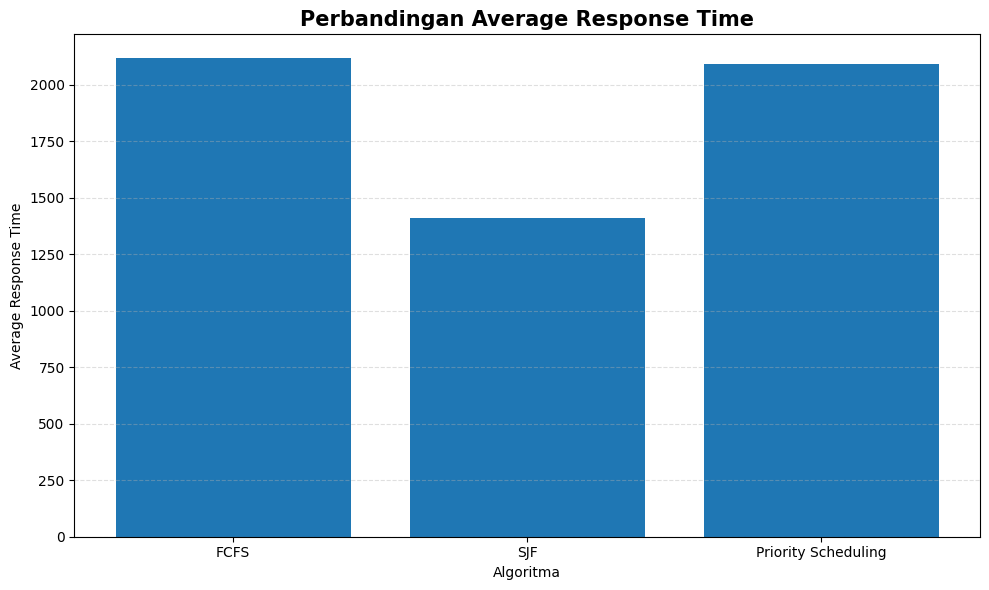

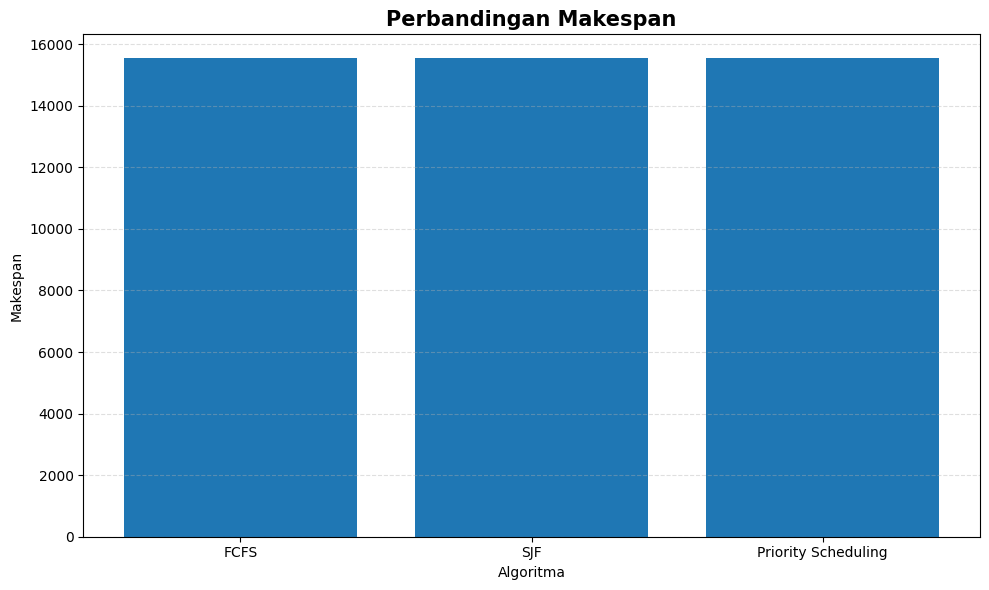

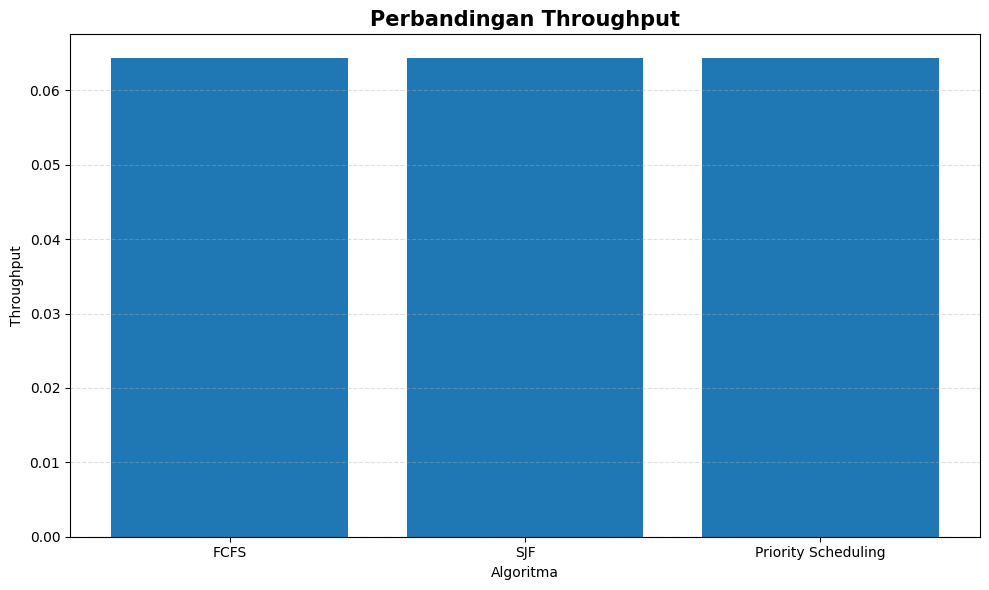

In [28]:
# ============================================================
# CELL 23 - GRAFIK PERBANDINGAN SEMUA METRIK
# ============================================================

metrics_to_plot = [
    "Average Waiting Time",
    "Average Turnaround Time",
    "Average Response Time",
    "Makespan",
    "Throughput"
]

# Membuat satu grafik untuk setiap metrik.
for metric in metrics_to_plot:

    plt.figure(figsize=(10, 6))

    plt.bar(
        comparison["Algorithm"],
        comparison[metric]
    )

    plt.title(
        f"Perbandingan {metric}",
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel("Algoritma")
    plt.ylabel(metric)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()

In [29]:
# ============================================================
# CELL 24 - GANTT CHART FCFS
# ============================================================

def create_gantt(result, algorithm_name):
    """
    Membuat Gantt Chart berdasarkan hasil scheduling.
    """

    # Membuat figure.
    plt.figure(figsize=(15, 8))

    # Mendapatkan daftar mesin.
    machines = sorted(
        result["Machine_ID"].unique()
    )

    # Membuat posisi vertikal untuk setiap mesin.
    machine_position = {
        machine: i
        for i, machine in enumerate(machines)
    }

    # Menggambar setiap job.
    for _, row in result.iterrows():

        # Posisi mesin.
        y = machine_position[row["Machine_ID"]]

        # Durasi pekerjaan.
        duration = (
            row["Completion_Time"] -
            row["Start_Time"]
        )

        # Membuat bar pekerjaan.
        plt.barh(
            y,
            duration,
            left=row["Start_Time"],
            height=0.5
        )

        # Menampilkan Job_ID di tengah bar.
        plt.text(
            row["Start_Time"] + duration / 2,
            y,
            str(row["Job_ID"]),
            ha="center",
            va="center",
            fontsize=8
        )

    # Mengatur nama mesin pada sumbu Y.
    plt.yticks(
        range(len(machines)),
        machines
    )

    # Judul grafik.
    plt.title(
        f"Gantt Chart - {algorithm_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        "Waktu Simulasi"
    )

    plt.ylabel(
        "Machine ID"
    )

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()
    plt.show()

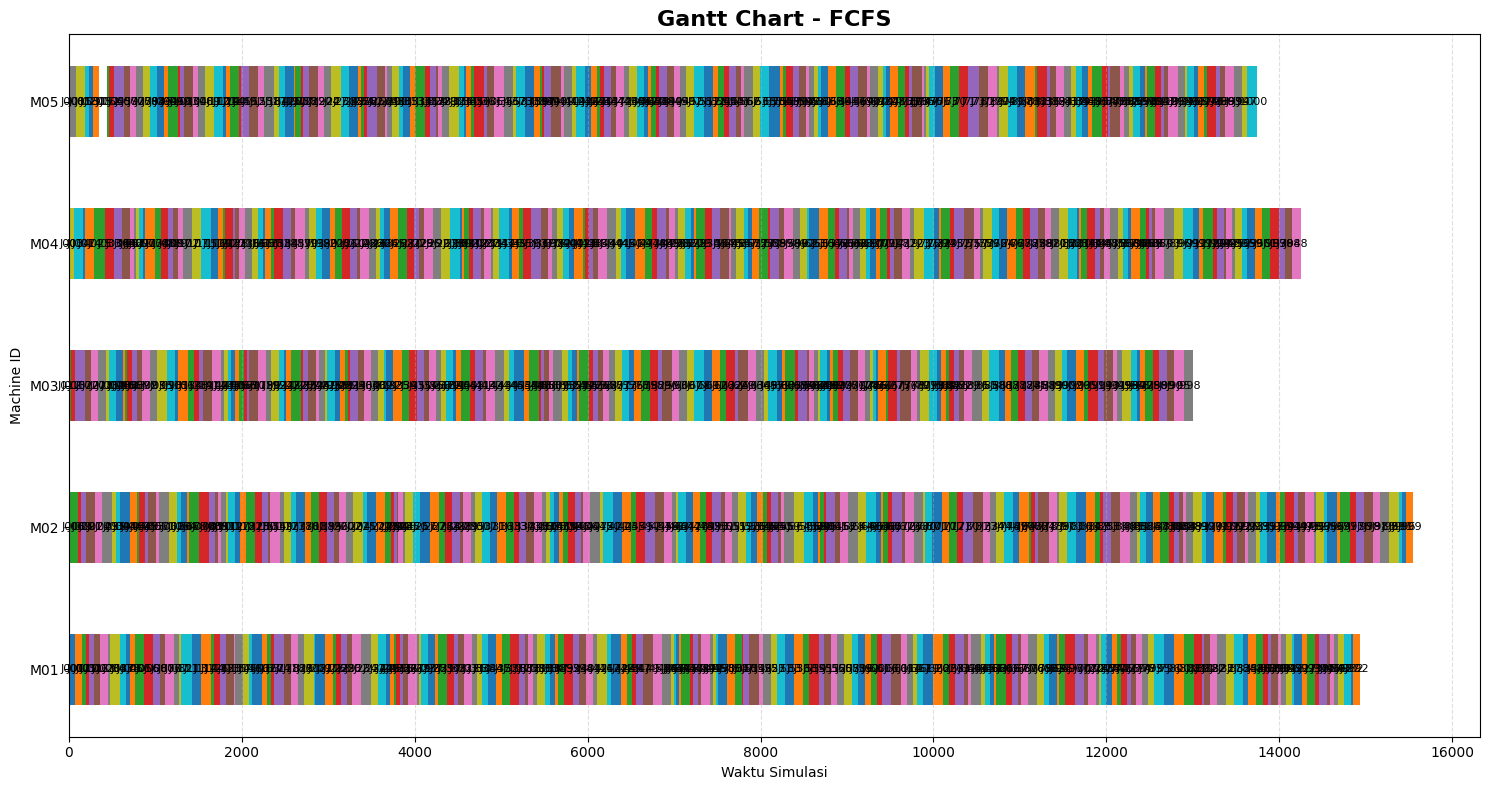

In [30]:
# Menampilkan Gantt Chart FCFS.
create_gantt(
    fcfs_result,
    "FCFS"
)

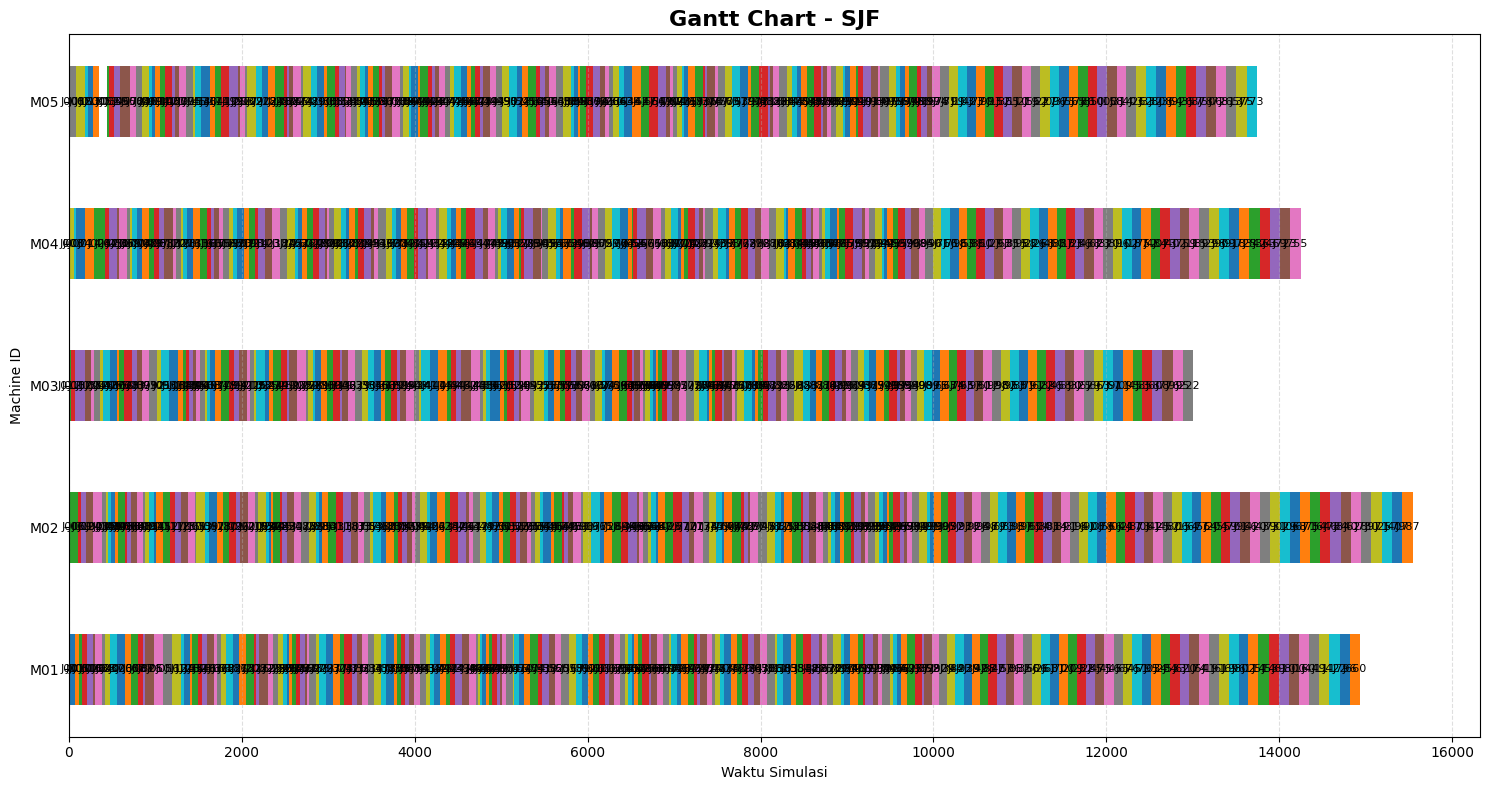

In [31]:
# ============================================================
# CELL 25 - GANTT CHART SJF
# ============================================================

create_gantt(
    sjf_result,
    "SJF"
)

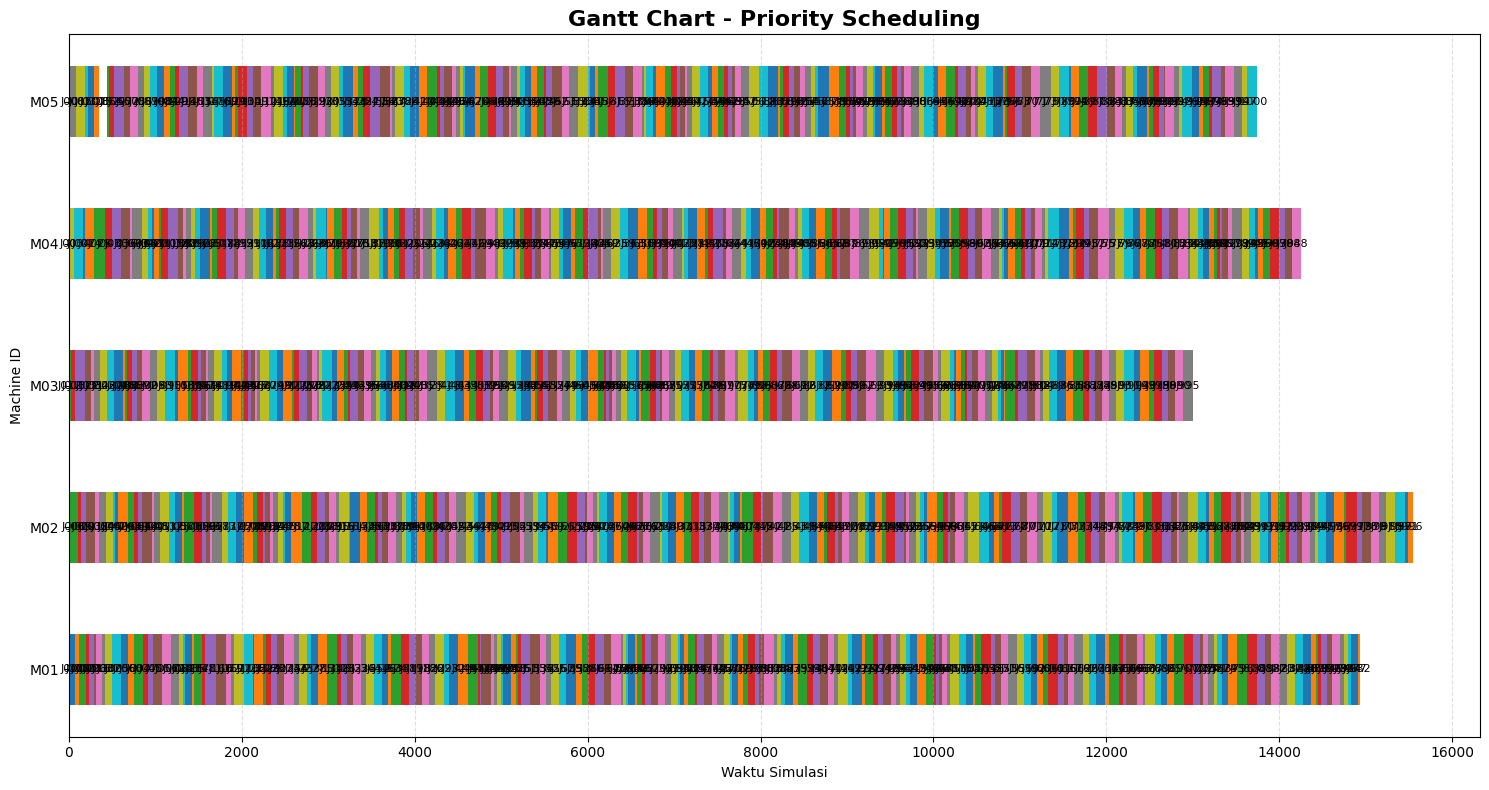

In [32]:
# ============================================================
# CELL 26 - GANTT CHART PRIORITY SCHEDULING
# ============================================================

create_gantt(
    priority_result,
    "Priority Scheduling"
)

In [33]:
# ============================================================
# CELL 27 - ANALISIS PER MESIN
# ============================================================

def machine_metrics(result, algorithm_name):
    """
    Menghitung metrik scheduling untuk setiap mesin.
    """

    rows = []

    # Melakukan perhitungan untuk setiap mesin.
    for machine_id, machine_data in result.groupby("Machine_ID"):

        # Average waiting time.
        avg_waiting = machine_data["Waiting_Time"].mean()

        # Average turnaround time.
        avg_turnaround = machine_data["Turnaround_Time"].mean()

        # Average response time.
        avg_response = machine_data["Response_Time"].mean()

        # Makespan mesin.
        makespan = machine_data["Completion_Time"].max()

        # Jumlah job pada mesin.
        total_jobs = len(machine_data)

        # Throughput mesin.
        throughput = (
            total_jobs / makespan
            if makespan > 0
            else 0
        )

        # Menyimpan hasil.
        rows.append({
            "Algorithm": algorithm_name,
            "Machine_ID": machine_id,
            "Number of Jobs": total_jobs,
            "Average Waiting Time": avg_waiting,
            "Average Turnaround Time": avg_turnaround,
            "Average Response Time": avg_response,
            "Makespan": makespan,
            "Throughput": throughput
        })

    return pd.DataFrame(rows)


# Menghitung metrik per mesin untuk FCFS.
machine_fcfs = machine_metrics(
    fcfs_result,
    "FCFS"
)

# Menghitung metrik per mesin untuk SJF.
machine_sjf = machine_metrics(
    sjf_result,
    "SJF"
)

# Menghitung metrik per mesin untuk Priority.
machine_priority = machine_metrics(
    priority_result,
    "Priority Scheduling"
)

# Menggabungkan hasil.
machine_comparison = pd.concat(
    [
        machine_fcfs,
        machine_sjf,
        machine_priority
    ],
    ignore_index=True
)

# Menampilkan hasil.
display(machine_comparison)

,Algorithm,Machine_ID,Number of Jobs,Average Waiting Time,Average Turnaround Time,Average Response Time,Makespan,Throughput
0,FCFS,M01,212,"2,660.95","2,731.41","2,660.95","14,937.00",0.01
1,FCFS,M02,210,"2,562.10","2,636.12","2,562.10","15,545.00",0.01
2,FCFS,M03,186,"1,239.56","1,309.47","1,239.56","13,004.00",0.01
3,FCFS,M04,199,"2,063.33","2,134.93","2,063.33","14,249.00",0.01
4,FCFS,M05,193,"1,934.79","2,005.51","1,934.79","13,743.00",0.01
5,SJF,M01,212,"1,747.28","1,817.74","1,747.28","14,937.00",0.01
6,SJF,M02,210,"1,745.06","1,819.08","1,745.06","15,545.00",0.01
7,SJF,M03,186,848.55,918.46,848.55,"13,004.00",0.01
8,SJF,M04,199,"1,378.70","1,450.31","1,378.70","14,249.00",0.01
9,SJF,M05,193,"1,254.11","1,324.83","1,254.11","13,743.00",0.01


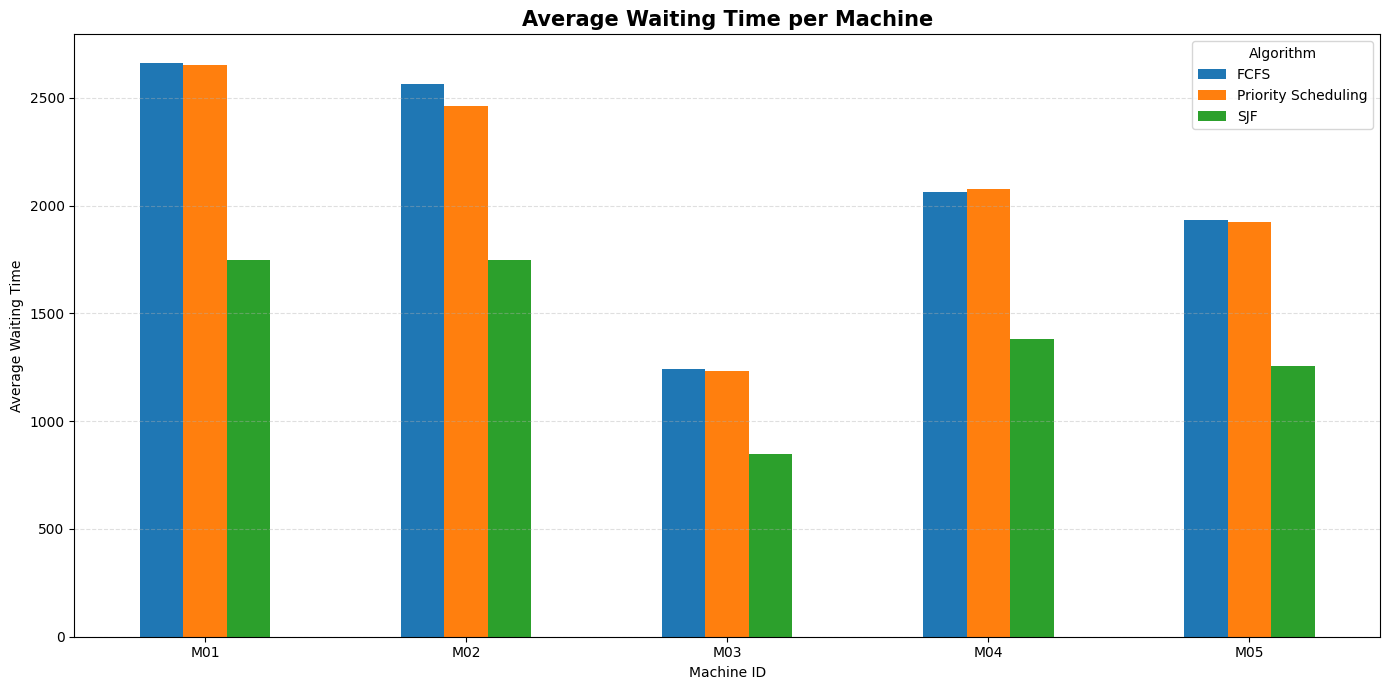

In [34]:
# ============================================================
# CELL 28 - GRAFIK WAITING TIME PER MESIN
# ============================================================

pivot_waiting = machine_comparison.pivot(
    index="Machine_ID",
    columns="Algorithm",
    values="Average Waiting Time"
)

pivot_waiting.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Average Waiting Time per Machine",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Machine ID")
plt.ylabel("Average Waiting Time")

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# CELL 30 - ANALISIS KONDISI PRODUKSI AKTUAL
# ============================================================

# Membuat dataframe khusus analisis aktual.
actual_analysis = data.copy()

# Menghitung durasi jadwal berdasarkan Scheduled_Start
# dan Scheduled_End dalam menit.
actual_analysis["Scheduled_Duration_Minutes"] = (
    actual_analysis["Scheduled_End"]
    - actual_analysis["Scheduled_Start"]
).dt.total_seconds() / 60

# Menghitung keterlambatan mulai produksi.
actual_analysis["Start_Delay_Minutes"] = (
    actual_analysis["Actual_Start"]
    - actual_analysis["Scheduled_Start"]
).dt.total_seconds() / 60

# Menghitung durasi aktual produksi.
actual_analysis["Actual_Duration_Minutes"] = (
    actual_analysis["Actual_End"]
    - actual_analysis["Actual_Start"]
).dt.total_seconds() / 60

# Menampilkan data analisis aktual.
actual_columns = [
    "Job_ID",
    "Machine_ID",
    "Scheduled_Start",
    "Scheduled_End",
    "Actual_Start",
    "Actual_End",
    "Scheduled_Duration_Minutes",
    "Actual_Duration_Minutes",
    "Start_Delay_Minutes",
    "Job_Status"
]

display(
    actual_analysis[actual_columns]
)

,Job_ID,Machine_ID,Scheduled_Start,Scheduled_End,Actual_Start,Actual_End,Scheduled_Duration_Minutes,Actual_Duration_Minutes,Start_Delay_Minutes,Job_Status
0,J001,M01,2023-03-18 08:00:00,2023-03-18 09:16:00,2023-03-18 08:05:00,2023-03-18 09:21:00,76.00,76.00,5.00,Completed
1,J002,M01,2023-03-18 08:10:00,2023-03-18 09:29:00,2023-03-18 08:20:00,2023-03-18 09:39:00,79.00,79.00,10.00,Delayed
2,J005,M01,2023-03-18 08:40:00,2023-03-18 09:26:00,2023-03-18 08:42:00,2023-03-18 09:28:00,46.00,46.00,2.00,Completed
3,J010,M01,2023-03-18 09:30:00,2023-03-18 09:57:00,2023-03-18 09:54:00,2023-03-18 10:21:00,27.00,27.00,24.00,Delayed
4,J011,M01,2023-03-18 09:40:00,2023-03-18 10:45:00,2023-03-18 09:38:00,2023-03-18 10:43:00,65.00,65.00,-2.00,Completed
...,...,...,...,...,...,...,...,...,...,...
995,J986,M05,2023-03-25 04:10:00,2023-03-25 05:10:00,2023-03-25 04:12:00,2023-03-25 05:12:00,60.00,60.00,2.00,Completed
996,J993,M05,2023-03-25 05:20:00,2023-03-25 07:05:00,2023-03-25 05:33:00,2023-03-25 07:18:00,105.00,105.00,13.00,Delayed
997,J994,M05,2023-03-25 05:30:00,2023-03-25 07:04:00,2023-03-25 05:27:00,2023-03-25 07:01:00,94.00,94.00,-3.00,Completed
998,J997,M05,2023-03-25 06:00:00,2023-03-25 07:00:00,NaT,NaT,60.00,NaN,NaN,Failed


Distribusi Job Status:


,Job Status,Jumlah Job
0,Completed,673
1,Delayed,198
2,Failed,129


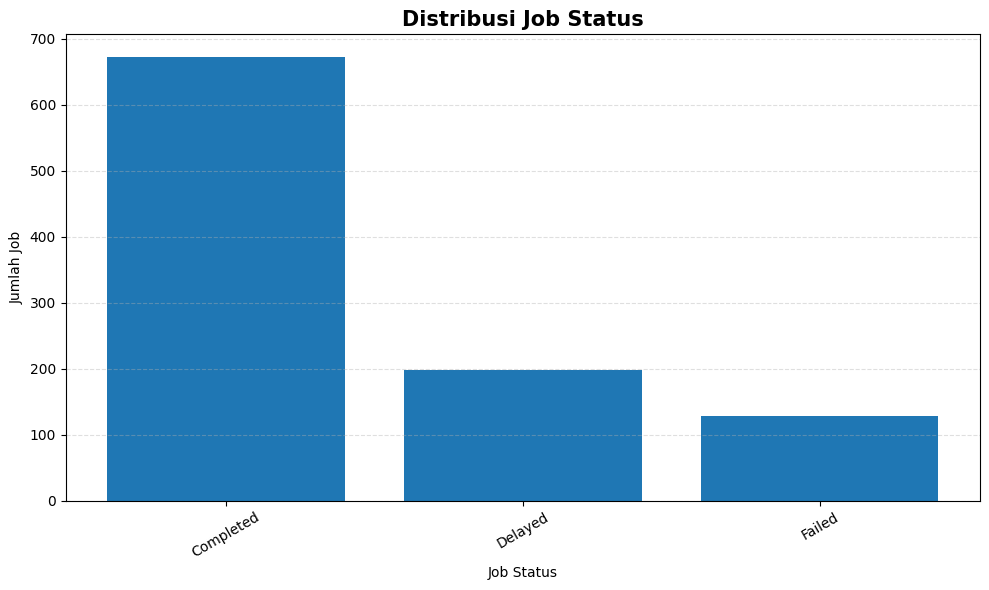

In [36]:
# ============================================================
# CELL 31 - ANALISIS JOB STATUS
# ============================================================

job_status_summary = (
    data["Job_Status"]
    .value_counts()
    .rename_axis("Job Status")
    .reset_index(name="Jumlah Job")
)

print("Distribusi Job Status:")
display(job_status_summary)

# Membuat grafik Job Status.
plt.figure(figsize=(10, 6))

plt.bar(
    job_status_summary["Job Status"],
    job_status_summary["Jumlah Job"]
)

plt.title(
    "Distribusi Job Status",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Job Status")
plt.ylabel("Jumlah Job")

plt.xticks(rotation=30)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

Distribusi Optimization Category:


,Optimization Category,Jumlah Job
0,Low Efficiency,650
1,Moderate Efficiency,183
2,High Efficiency,161
3,Optimal Efficiency,6


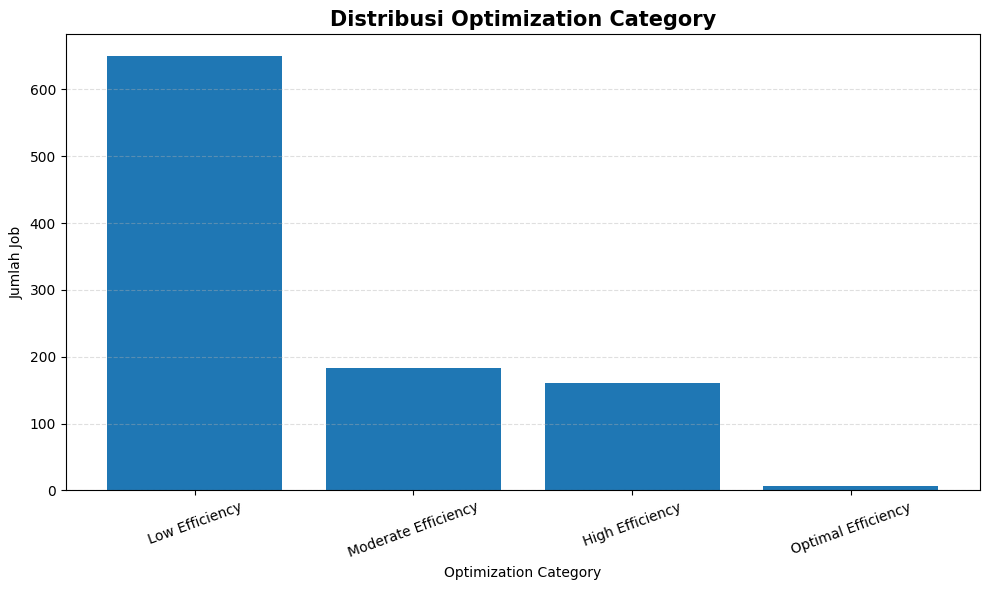

In [37]:
# ============================================================
# CELL 32 - ANALISIS OPTIMIZATION CATEGORY
# ============================================================

efficiency_summary = (
    data["Optimization_Category"]
    .value_counts()
    .rename_axis("Optimization Category")
    .reset_index(name="Jumlah Job")
)

print("Distribusi Optimization Category:")
display(efficiency_summary)

# Grafik kategori efisiensi.
plt.figure(figsize=(10, 6))

plt.bar(
    efficiency_summary["Optimization Category"],
    efficiency_summary["Jumlah Job"]
)

plt.title(
    "Distribusi Optimization Category",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Optimization Category")
plt.ylabel("Jumlah Job")

plt.xticks(rotation=20)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

Statistik Processing Time:


,Processing_Time
count,"1,000.00"
mean,71.38
std,28.48
min,20.00
25%,48.00
50%,72.00
75%,96.00
max,120.00


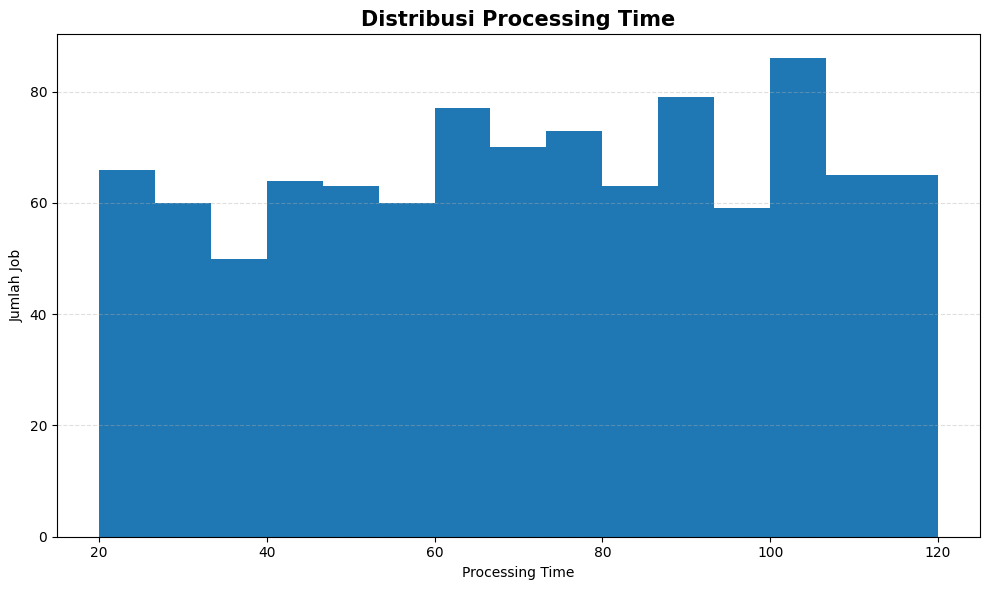

In [38]:
# ============================================================
# CELL 33 - ANALISIS PROCESSING TIME
# ============================================================

processing_summary = data["Processing_Time"].describe()

print("Statistik Processing Time:")
display(
    processing_summary.to_frame("Processing_Time")
)

# Histogram Processing Time.
plt.figure(figsize=(10, 6))

plt.hist(
    data["Processing_Time"],
    bins=15
)

plt.title(
    "Distribusi Processing Time",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Processing Time"
)

plt.ylabel(
    "Jumlah Job"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

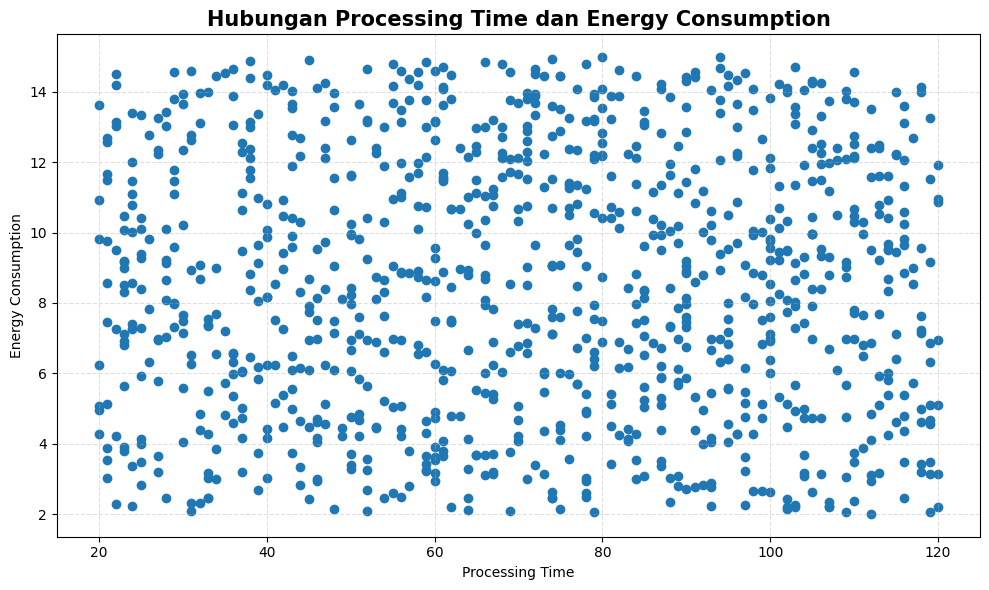

In [39]:
# ============================================================
# CELL 34 - HUBUNGAN PROCESSING TIME DAN ENERGY
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    data["Processing_Time"],
    data["Energy_Consumption"]
)

plt.title(
    "Hubungan Processing Time dan Energy Consumption",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Processing Time")
plt.ylabel("Energy Consumption")

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# CELL 35 - RINGKASAN STATISTIK
# ============================================================

summary_statistics = pd.DataFrame({
    "Metric": [
        "Average Waiting Time",
        "Average Turnaround Time",
        "Average Response Time",
        "Makespan",
        "Throughput"
    ],

    "FCFS": [
        fcfs_metrics["Average Waiting Time"],
        fcfs_metrics["Average Turnaround Time"],
        fcfs_metrics["Average Response Time"],
        fcfs_metrics["Makespan"],
        fcfs_metrics["Throughput"]
    ],

    "SJF": [
        sjf_metrics["Average Waiting Time"],
        sjf_metrics["Average Turnaround Time"],
        sjf_metrics["Average Response Time"],
        sjf_metrics["Makespan"],
        sjf_metrics["Throughput"]
    ],

    "Priority Scheduling": [
        priority_metrics["Average Waiting Time"],
        priority_metrics["Average Turnaround Time"],
        priority_metrics["Average Response Time"],
        priority_metrics["Makespan"],
        priority_metrics["Throughput"]
    ]
})

display(summary_statistics)

,Metric,FCFS,SJF,Priority Scheduling
0,Average Waiting Time,"2,116.74","1,411.12","2,092.44"
1,Average Turnaround Time,"2,188.12","1,482.51","2,163.82"
2,Average Response Time,"2,116.74","1,411.12","2,092.44"
3,Makespan,"15,545.00","15,545.00","15,545.00"
4,Throughput,0.06,0.06,0.06


In [41]:
# ============================================================
# CELL 36 - ANALISIS OTOMATIS
# ============================================================

print("=" * 90)
print("ANALISIS HASIL SIMULASI")
print("=" * 90)

# Mencari nilai minimum waiting time.
min_waiting = comparison["Average Waiting Time"].min()

# Mencari algoritma dengan nilai tersebut.
waiting_algorithms = comparison.loc[
    comparison["Average Waiting Time"] == min_waiting,
    "Algorithm"
].tolist()

print("\n1. Average Waiting Time")
print(
    f"Nilai minimum = {min_waiting:.4f}"
)
print(
    "Algoritma dengan nilai tersebut:",
    ", ".join(waiting_algorithms)
)

# Mencari turnaround minimum.
min_turnaround = comparison["Average Turnaround Time"].min()

turnaround_algorithms = comparison.loc[
    comparison["Average Turnaround Time"] == min_turnaround,
    "Algorithm"
].tolist()

print("\n2. Average Turnaround Time")
print(
    f"Nilai minimum = {min_turnaround:.4f}"
)
print(
    "Algoritma dengan nilai tersebut:",
    ", ".join(turnaround_algorithms)
)

# Mencari response minimum.
min_response = comparison["Average Response Time"].min()

response_algorithms = comparison.loc[
    comparison["Average Response Time"] == min_response,
    "Algorithm"
].tolist()

print("\n3. Average Response Time")
print(
    f"Nilai minimum = {min_response:.4f}"
)
print(
    "Algoritma dengan nilai tersebut:",
    ", ".join(response_algorithms)
)

# Mencari makespan minimum.
min_makespan = comparison["Makespan"].min()

makespan_algorithms = comparison.loc[
    comparison["Makespan"] == min_makespan,
    "Algorithm"
].tolist()

print("\n4. Makespan")
print(
    f"Nilai minimum = {min_makespan:.4f}"
)
print(
    "Algoritma dengan nilai tersebut:",
    ", ".join(makespan_algorithms)
)

# Mencari throughput maksimum.
max_throughput = comparison["Throughput"].max()

throughput_algorithms = comparison.loc[
    comparison["Throughput"] == max_throughput,
    "Algorithm"
].tolist()

print("\n5. Throughput")
print(
    f"Nilai maksimum = {max_throughput:.6f}"
)
print(
    "Algoritma dengan nilai tersebut:",
    ", ".join(throughput_algorithms)
)

ANALISIS HASIL SIMULASI

1. Average Waiting Time
Nilai minimum = 1411.1210
Algoritma dengan nilai tersebut: SJF

2. Average Turnaround Time
Nilai minimum = 1482.5050
Algoritma dengan nilai tersebut: SJF

3. Average Response Time
Nilai minimum = 1411.1210
Algoritma dengan nilai tersebut: SJF

4. Makespan
Nilai minimum = 15545.0000
Algoritma dengan nilai tersebut: FCFS, SJF, Priority Scheduling

5. Throughput
Nilai maksimum = 0.064329
Algoritma dengan nilai tersebut: FCFS, SJF, Priority Scheduling


In [42]:
# ============================================================
# CELL 37 - MEMBUAT FOLDER OUTPUT
# ============================================================

# Nama folder hasil penelitian.
OUTPUT_DIR = "hasil_analisis_manufaktur"

# Membuat folder jika belum tersedia.
os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

print(
    f"Folder hasil tersedia: {OUTPUT_DIR}"
)

Folder hasil tersedia: hasil_analisis_manufaktur


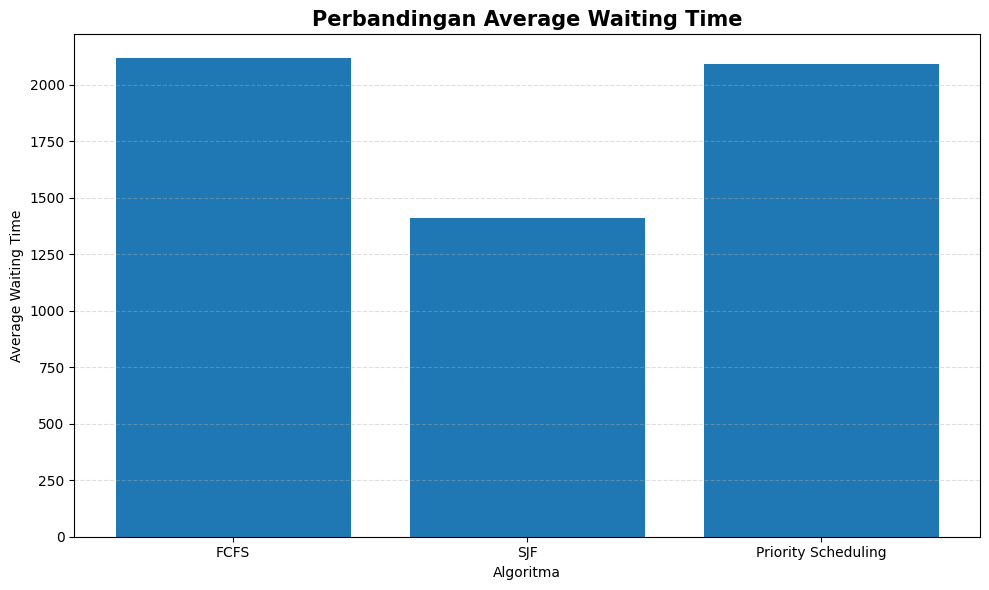

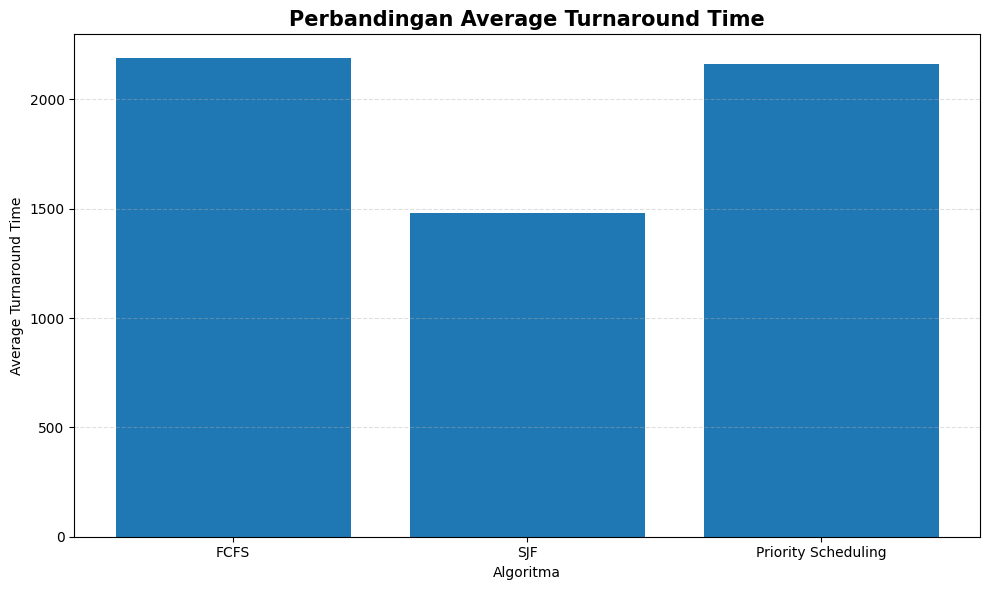

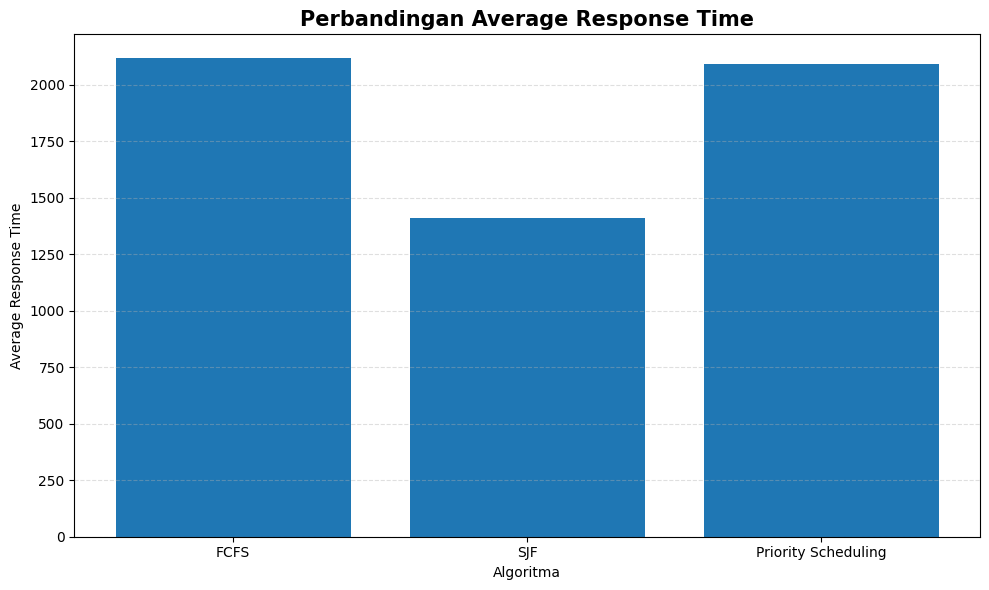

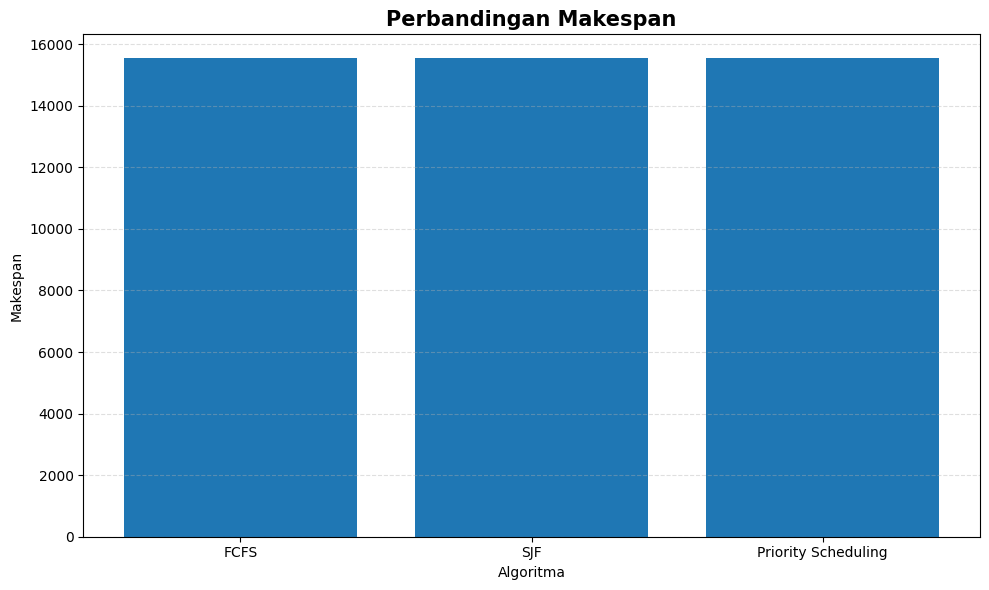

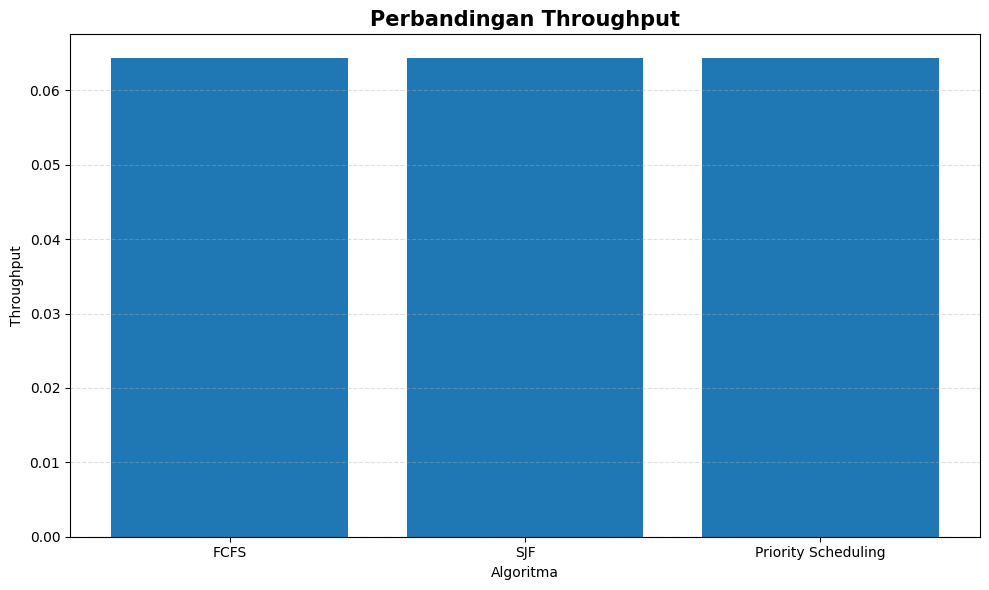

In [43]:
# ============================================================
# CELL 38 - MENYIMPAN GRAFIK
# ============================================================

def save_bar_chart(
    x,
    y,
    title,
    xlabel,
    ylabel,
    filename
):
    """
    Fungsi untuk membuat dan menyimpan grafik batang.
    """

    plt.figure(figsize=(10, 6))

    plt.bar(x, y)

    plt.title(
        title,
        fontsize=15,
        fontweight="bold"
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    # Menyimpan gambar.
    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    # Menutup figure agar tidak menumpuk.
    plt.close()


# Menyimpan Waiting Time.
save_bar_chart(
    comparison["Algorithm"],
    comparison["Average Waiting Time"],
    "Perbandingan Average Waiting Time",
    "Algoritma",
    "Average Waiting Time",
    "01_average_waiting_time.png"
)

# Menyimpan Turnaround Time.
save_bar_chart(
    comparison["Algorithm"],
    comparison["Average Turnaround Time"],
    "Perbandingan Average Turnaround Time",
    "Algoritma",
    "Average Turnaround Time",
    "02_average_turnaround_time.png"
)

# Menyimpan Response Time.
save_bar_chart(
    comparison["Algorithm"],
    comparison["Average Response Time"],
    "Perbandingan Average Response Time",
    "Algoritma",
    "Average Response Time",
    "03_average_response_time.png"
)

# Menyimpan Makespan.
save_bar_chart(
    comparison["Algorithm"],
    comparison["Makespan"],
    "Perbandingan Makespan",
    "Algoritma",
    "Makespan",
    "04_makespan.png"
)

# Menyimpan Throughput.
save_bar_chart(
    comparison["Algorithm"],
    comparison["Throughput"],
    "Perbandingan Throughput",
    "Algoritma",
    "Throughput",
    "05_throughput.png"
)

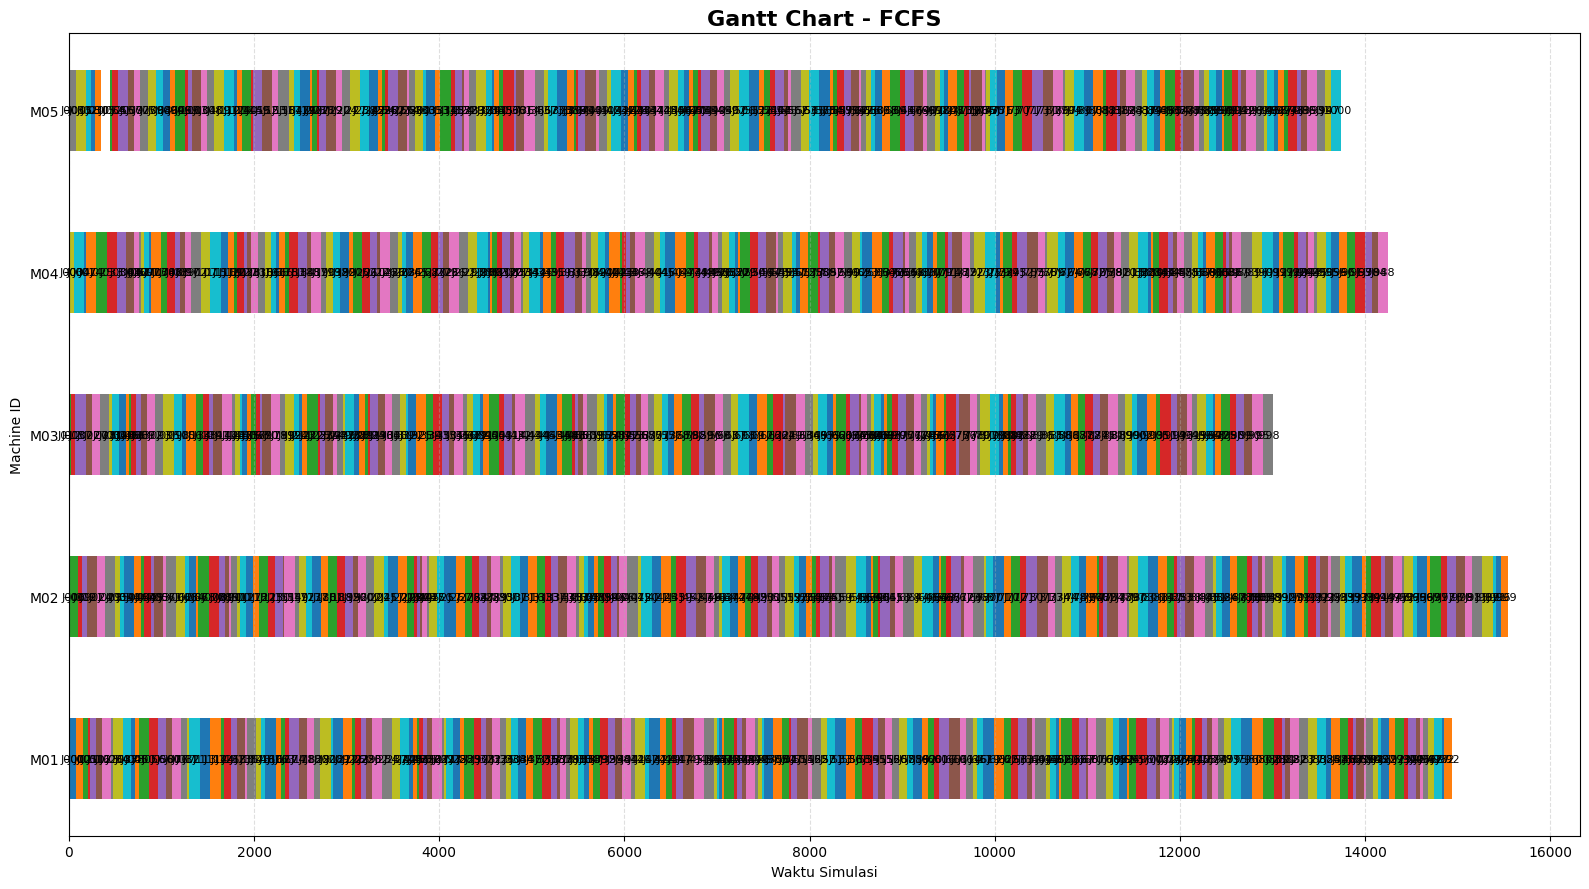

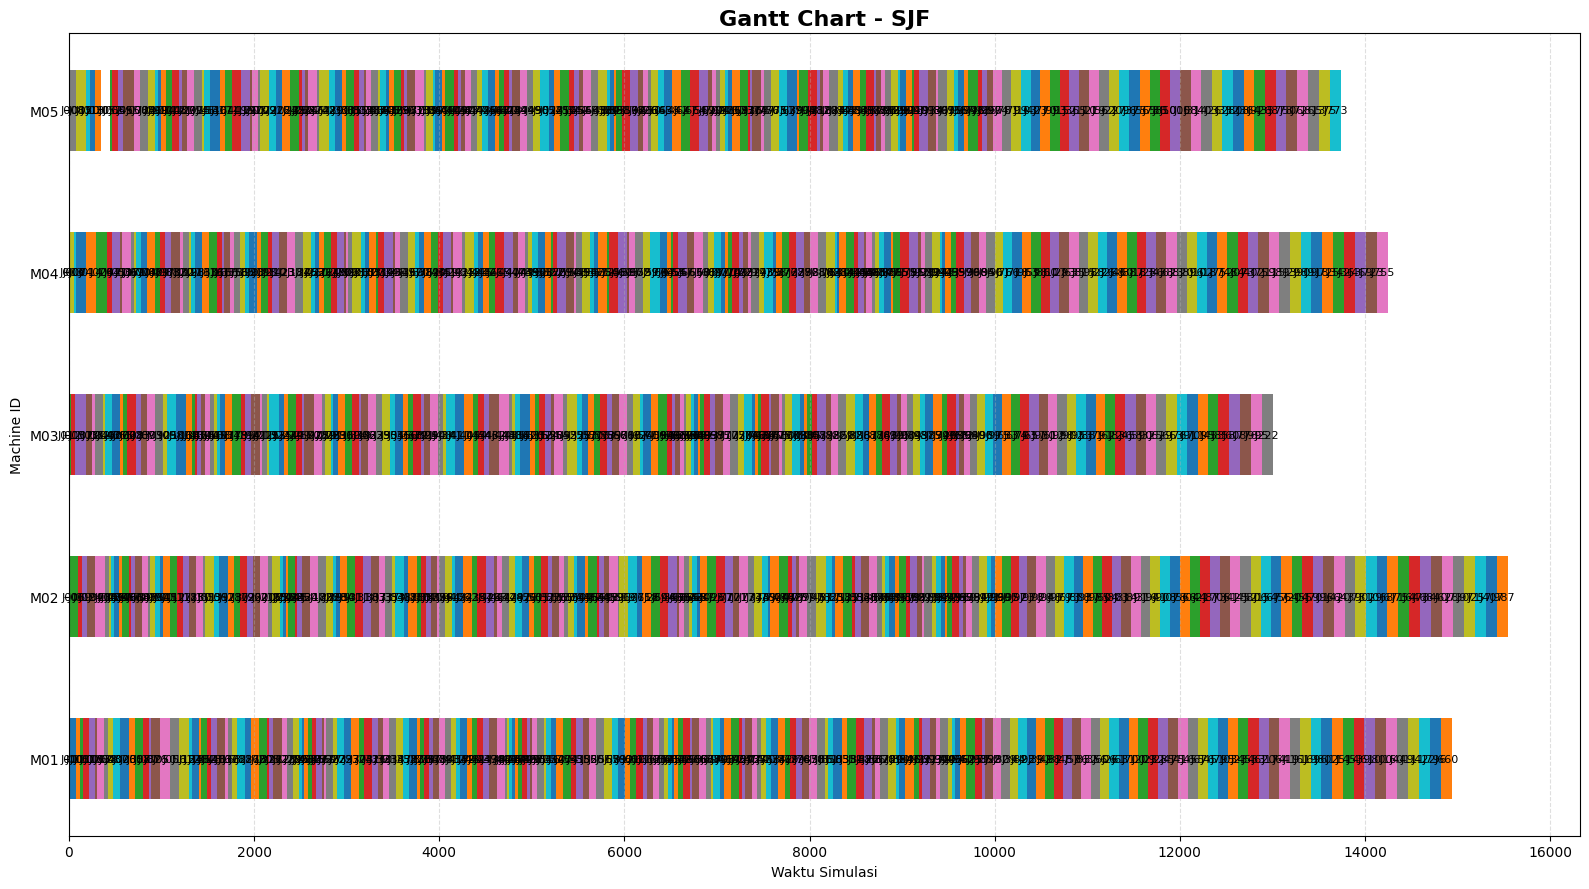

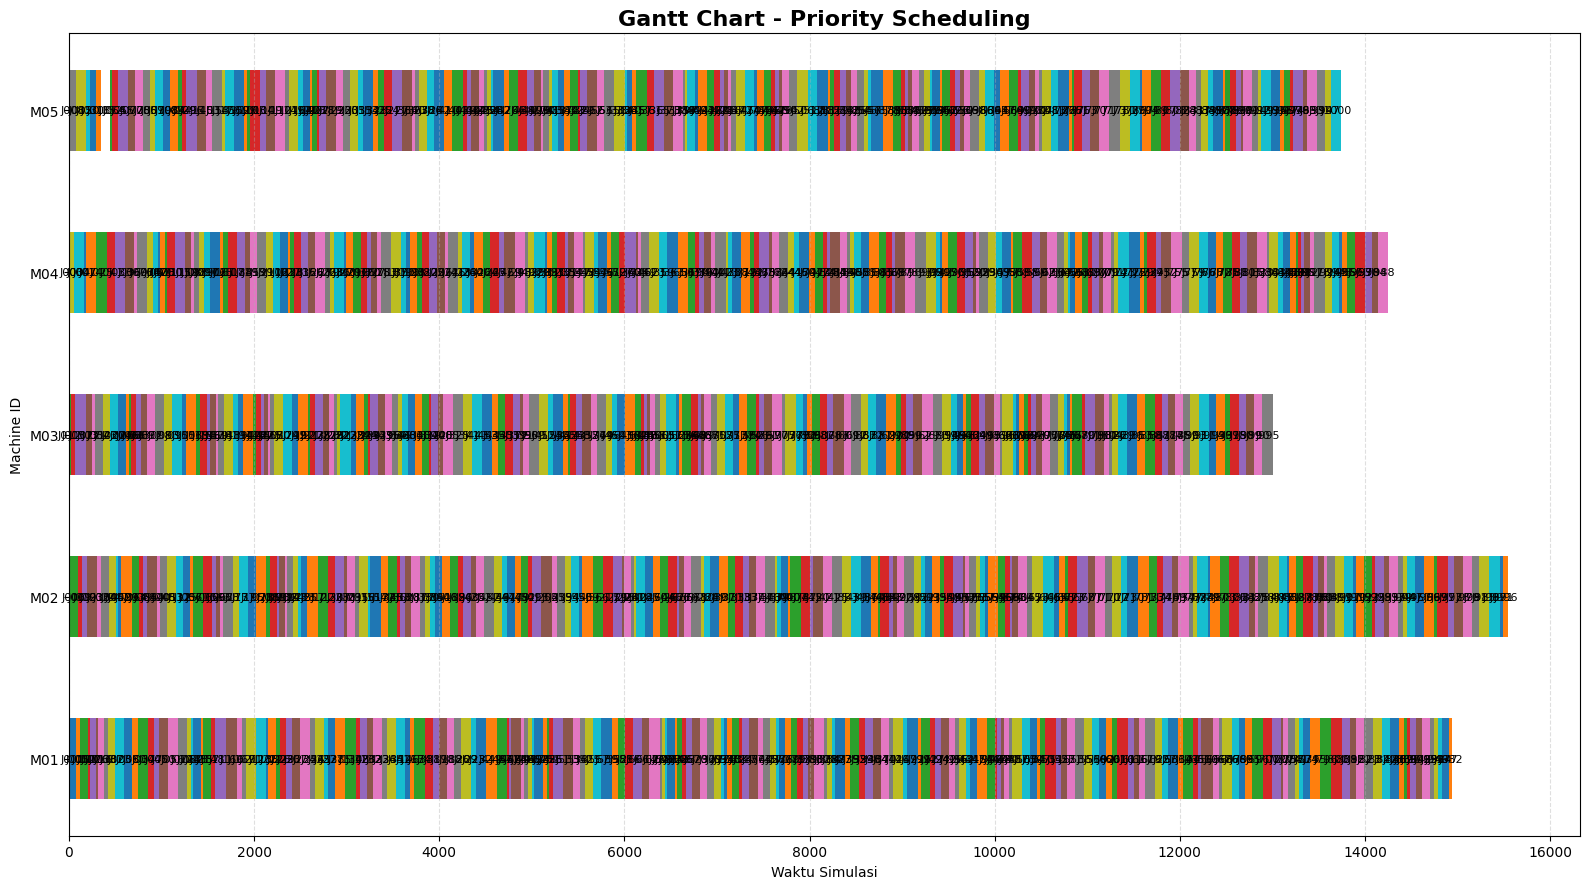

In [44]:
# ============================================================
# CELL 39 - MENYIMPAN GANTT CHART
# ============================================================

def save_gantt(result, algorithm_name, filename):
    """
    Membuat dan menyimpan Gantt Chart.
    """

    plt.figure(figsize=(16, 9))

    # Mendapatkan daftar mesin.
    machines = sorted(
        result["Machine_ID"].unique()
    )

    # Membuat posisi mesin.
    machine_position = {
        machine: i
        for i, machine in enumerate(machines)
    }

    # Menggambar setiap pekerjaan.
    for _, row in result.iterrows():

        y = machine_position[row["Machine_ID"]]

        duration = (
            row["Completion_Time"] -
            row["Start_Time"]
        )

        plt.barh(
            y,
            duration,
            left=row["Start_Time"],
            height=0.5
        )

        plt.text(
            row["Start_Time"] + duration / 2,
            y,
            str(row["Job_ID"]),
            ha="center",
            va="center",
            fontsize=8
        )

    plt.yticks(
        range(len(machines)),
        machines
    )

    plt.title(
        f"Gantt Chart - {algorithm_name}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(
        "Waktu Simulasi"
    )

    plt.ylabel(
        "Machine ID"
    )

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            filename
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


# Gantt FCFS.
save_gantt(
    fcfs_result,
    "FCFS",
    "06_gantt_fcfs.png"
)

# Gantt SJF.
save_gantt(
    sjf_result,
    "SJF",
    "07_gantt_sjf.png"
)

# Gantt Priority.
save_gantt(
    priority_result,
    "Priority Scheduling",
    "08_gantt_priority.png"
)

In [45]:
# ============================================================
# CELL 40 - EXPORT HASIL KE EXCEL
# ============================================================

# Nama file Excel.
excel_file = os.path.join(
    OUTPUT_DIR,
    "hasil_analisis_FCFS_SJF_Priority.xlsx"
)

# Membuka ExcelWriter menggunakan openpyxl.
with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    # ========================================================
    # DATA ASLI
    # ========================================================

    df.to_excel(
        writer,
        sheet_name="Data Asli",
        index=False
    )

    # ========================================================
    # DATA PREPROCESSING
    # ========================================================

    data.to_excel(
        writer,
        sheet_name="Preprocessing",
        index=False
    )

    # ========================================================
    # DATA SIMULASI
    # ========================================================

    simulation_data.to_excel(
        writer,
        sheet_name="Data Simulasi",
        index=False
    )

    # ========================================================
    # HASIL FCFS
    # ========================================================

    fcfs_result.to_excel(
        writer,
        sheet_name="FCFS",
        index=False
    )

    # ========================================================
    # HASIL SJF
    # ========================================================

    sjf_result.to_excel(
        writer,
        sheet_name="SJF",
        index=False
    )

    # ========================================================
    # HASIL PRIORITY
    # ========================================================

    priority_result.to_excel(
        writer,
        sheet_name="Priority",
        index=False
    )

    # ========================================================
    # PERBANDINGAN
    # ========================================================

    comparison.to_excel(
        writer,
        sheet_name="Perbandingan",
        index=False
    )

    # ========================================================
    # STATISTIK
    # ========================================================

    summary_statistics.to_excel(
        writer,
        sheet_name="Ringkasan Statistik",
        index=False
    )

    # ========================================================
    # ANALISIS PER MESIN
    # ========================================================

    machine_comparison.to_excel(
        writer,
        sheet_name="Per Mesin",
        index=False
    )

    # ========================================================
    # JOB STATUS
    # ========================================================

    job_status_summary.to_excel(
        writer,
        sheet_name="Job Status",
        index=False
    )

    # ========================================================
    # OPTIMIZATION CATEGORY
    # ========================================================

    efficiency_summary.to_excel(
        writer,
        sheet_name="Efficiency Category",
        index=False
    )

    # ========================================================
    # PRIORITY MAPPING
    # ========================================================

    priority_reference.to_excel(
        writer,
        sheet_name="Priority Mapping",
        index=False
    )

    # ========================================================
    # ANALISIS DATA AKTUAL
    # ========================================================

    actual_analysis.to_excel(
        writer,
        sheet_name="Analisis Aktual",
        index=False
    )

print("Excel berhasil dibuat:")
print(excel_file)

Excel berhasil dibuat:
hasil_analisis_manufaktur/hasil_analisis_FCFS_SJF_Priority.xlsx


In [46]:
# ============================================================
# CELL 41 - MEMBUAT FILE ZIP
# ============================================================

# Nama file ZIP.
zip_file = "hasil_analisis_FCFS_SJF_Priority.zip"

# Menghapus ZIP lama jika ada.
if os.path.exists(zip_file):
    os.remove(zip_file)

# Membuat ZIP.
with zipfile.ZipFile(
    zip_file,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    # Memasukkan semua file dari folder output.
    for root, dirs, files_list in os.walk(OUTPUT_DIR):

        for file in files_list:

            file_path = os.path.join(
                root,
                file
            )

            # Menentukan nama relatif di dalam ZIP.
            arcname = os.path.relpath(
                file_path,
                OUTPUT_DIR
            )

            zipf.write(
                file_path,
                arcname
            )

print("ZIP berhasil dibuat:")
print(zip_file)

ZIP berhasil dibuat:
hasil_analisis_FCFS_SJF_Priority.zip


In [47]:
# ============================================================
# CELL 42 - DAFTAR HASIL
# ============================================================

print("=" * 80)
print("DAFTAR FILE HASIL ANALISIS")
print("=" * 80)

for root, dirs, files_list in os.walk(OUTPUT_DIR):

    for file in files_list:

        print(
            os.path.join(
                root,
                file
            )
        )

DAFTAR FILE HASIL ANALISIS
hasil_analisis_manufaktur/01_average_waiting_time.png
hasil_analisis_manufaktur/06_gantt_fcfs.png
hasil_analisis_manufaktur/03_average_response_time.png
hasil_analisis_manufaktur/02_average_turnaround_time.png
hasil_analisis_manufaktur/07_gantt_sjf.png
hasil_analisis_manufaktur/04_makespan.png
hasil_analisis_manufaktur/05_throughput.png
hasil_analisis_manufaktur/hasil_analisis_FCFS_SJF_Priority.xlsx
hasil_analisis_manufaktur/08_gantt_priority.png


In [48]:
# ============================================================
# CELL 43 - DOWNLOAD EXCEL
# ============================================================

print("Download file Excel sedang disiapkan...")

files.download(
    excel_file
)

Download file Excel sedang disiapkan...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
# ============================================================
# CELL 44 - DOWNLOAD ZIP
# ============================================================

print("Download ZIP sedang disiapkan...")

files.download(
    zip_file
)

Download ZIP sedang disiapkan...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>